<h1 align='center'> Netfix Content Exploratory Data Analysis (EDA) </h1>

<h2>1. Project Overview</h2>

### Problem Statement
Netflix produces thousands of movies and TV shows across multiple countries and genres. However, stakeholders often ask:
- Which countries dominate Netflix Content production?
- How have content types evolved over time?
- What are the most popular genres and ratings?
- Are Netflix movies following the typical feature-length duration?

This project aims to analyze Netflix content data and build a visual dashboard that answers these questions in a clear, actionable way.

<br /> 

---

### Objectives
1. Analyze trends incontent type (Movies vs. TV Shows) over time.
2. Identify top producing countries and their trends.
3. Visualize genre popularity and highlight peaks and declines.
4. Examine movie durations to identify "sweet spots".
5. Present ratings distribution for insights into content maturity.
6. Create a single dashboard combining all these visuals for storytelling.

<br />

---

### Data
- __Source__: Netflix content dataset (csv), 
  - __Dataset:__ Netflix Shows (Kaggle): https://www.kaggle.com/datasets/infamouscoder/dataset-netflix-shows

<br />

- Columns include:
   - `title`, `type`, `date_added`, `country`, `release_year`, `genre`, `duration`, `rating`
 
<br />

---

### Data Overview & Inspection

#### Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv('Netflix_Show_Dataset.zip', compression='zip')
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


> This loads the dataset into a pandas DataFrame so we can inspect, clean, and analyze it.

#### Inspect Structure and Data Types

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


> Dataset `info()` and `describe()` helps us understand:
>* __number of rows and columns__ : here `8807 rows` and `12 columns`
>* __data types__ (object, int, datetime, etc.): here one `int64` and 11 `object`
>* __missing values__: `director`, `cast`, `country`, etc.
>* __unique values__ in categorical columns
>  
> This tells us what needs cleaning and data type convertion.

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Type Transformation

* `date_added` to datetime:

In [4]:
df['date_added']=df['date_added'].str.strip()
df['date_added']=pd.to_datetime(df['date_added'], errors='coerce')

print("Missing after convertion:", df['date_added'].isna().sum())

Missing after convertion: 10


> It is important to convert the `date_added` column from a basic string format to a datetime format that will be valuable later for the EDA section.
>
> * __Before__: September 25, 2021  → string
>
> * __After__: 2021-09-25 → datetime
>
> This allows us to extract:
> * year added
> * month added
> * time trends
>
> `errors='coerce'` converts invalid values to `NaT` instead of crashing.

* `type`, `rating`, `country`, `director`:

In [5]:
categorical_columns = ['type', 'rating', 'country', 'director']

for col in categorical_columns:
    df[col] = df[col].astype('category')

>These columns contain repeated labels, like:
>* Movie / TV Show
>* TV-MA / PG-13
>* United States / India
>
> Using category:
>* reduces memory usage
>* speeds up grouping and plotting
>* improves performance

### Fill Missing Values

In [6]:
categorical_cols = ['director', 'cast', 'country', 'rating', 'type']

for col in categorical_columns:
    df[col] = df[col].astype('object')
    df[col] = df[col].fillna('Unknown')
    df[col] = df[col].astype('category')

> Missing values cause problems in:
>* grouping
>* plotting
>* counting

In [7]:
df['duration']=df['duration'].fillna('Unknown')

> Duration column contains values like:
> * 90 min
> * Seasons
>
> Missing values would break parsing later.

### Duplicates Check

In [8]:
print("Duplicate titles:", df['title'].duplicated().sum())

Duplicate titles: 0


> __Dataset is clean.__

## Feature Engineering

* `numeric duration`, and
* `unit`

In [9]:
df[['duration_int', 'duration_unit']] = df['duration'].str.extract(r'(\d+)\s*(\w+)')

df['duration_int'] = pd.to_numeric(df['duration_int'], errors='coerce')

df['duration_unit'] = df['duration_unit'].replace({
    'Season': 'Seasons',
    'Seasons': 'Seasons',
    'min': 'Minutes'
})

> Original duration column mixes two types, so we split into:
> * duration_int (e.g. 90, 2)
> * duration_unit (e.g Minutes, Seasons)
>
> This allows:
>* movie duration analysis
>* TV season analysis
>* histograms
>* filtering

### Fill Missing Duration Components

In [10]:
df['duration_int'] = df['duration_int'].fillna(0).astype(int)

df['duration_unit'] = df['duration_unit'].fillna('Unknown')

> Ensures clean numeric column with no NaN values.

### Convert Genre Column from String → List

In [11]:
df['genre'] = df['listed_in'].apply(
    lambda x: [genre.strip() for genre in x.split(',')]
)

> This allows:
> * genre counting
> * exploding genres
> * genre trends over time

### Create New Time Features

In [12]:
df['added_month'] = df['date_added'].dt.month
df['added_year'] = df['date_added'].dt.year

> This enables analysis like:
>* titles added per year
>* trends over time
>* seasonal patterns

### Fill Missing Time Values

In [13]:
df['added_month'] = df['added_month'].fillna(0).astype(int)
df['added_year'] = df['added_year'].fillna(0).astype(int)

## Dataset Structure & Check

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   object        
 1   type           8807 non-null   category      
 2   title          8807 non-null   object        
 3   director       8807 non-null   category      
 4   cast           7982 non-null   object        
 5   country        8807 non-null   category      
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8807 non-null   int64         
 8   rating         8807 non-null   category      
 9   duration       8807 non-null   object        
 10  listed_in      8807 non-null   object        
 11  description    8807 non-null   object        
 12  duration_int   8807 non-null   int64         
 13  duration_unit  8807 non-null   object        
 14  genre          8807 non-null   object        
 15  added_month    8807 n

In [15]:
# FINAL CHANGE
df['cast'] = df['cast'].fillna('Unknown').astype('category')

df['duration_unit'] = df['duration_unit'].astype('category')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   object        
 1   type           8807 non-null   category      
 2   title          8807 non-null   object        
 3   director       8807 non-null   category      
 4   cast           8807 non-null   category      
 5   country        8807 non-null   category      
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8807 non-null   int64         
 8   rating         8807 non-null   category      
 9   duration       8807 non-null   object        
 10  listed_in      8807 non-null   object        
 11  description    8807 non-null   object        
 12  duration_int   8807 non-null   int64         
 13  duration_unit  8807 non-null   category      
 14  genre          8807 non-null   object        
 15  added_month    8807 n

In [17]:
df.to_csv('netflix_clean.csv', index=False)

> Dataset Ready

<br />

---

### Exploratory Analysis on Netflix Dataset

#### Dataset Overview

In [18]:
# Counts per type
print(df['type'].value_counts())

# Missing values check
print(df.isna().sum())

# Top 10 directors
print(df['director'].value_counts().head(10))

# Top 10 countries
print(df['country'].value_counts().head(10))

# Most common genres
from collections import Counter
genre_counts = Counter([genre for sublist in df['genre'] for genre in sublist])
print(genre_counts.most_common(10))

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added       10
release_year      0
rating            0
duration          0
listed_in         0
description       0
duration_int      0
duration_unit     0
genre             0
added_month       0
added_year        0
dtype: int64
director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Suhas Kadav                 16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Martin Scorsese             12
Jay Chapman                 12
Name: count, dtype: int64
country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
N

In [19]:
from tabulate import tabulate
from collections import Counter

# Most common genres
genre_counts = Counter([genre for sublist in df['genre'] for genre in sublist])
top_genre, top_genre_count = genre_counts.most_common(1)[0]

# Top director
top_director = df['director'].value_counts().idxmax()
top_director_count = df['director'].value_counts().max()

# Top country
top_country = df['country'].value_counts().idxmax()
top_country_count = df['country'].value_counts().max()

# Top rating
top_rating = df['rating'].value_counts().idxmax()
top_rating_count = df['rating'].value_counts().max()

# Dataset Overview Table
overview = [
    ["Total Shows", df.shape[0], "-", "-", "All entries in dataset"],
    ["Types of Shows", df['type'].nunique(), df['type'].mode()[0], df['type'].value_counts().max(), "Movies vs TV Shows"],
    ["Directors", df['director'].nunique(), top_director, top_director_count, "Most frequent director"],
    ["Countries", df['country'].nunique(), top_country, top_country_count, "Most shows from this country"],
    ["Ratings", df['rating'].nunique(), top_rating, top_rating_count, "Most common rating"],
    ["Genres", len(genre_counts), top_genre, top_genre_count, "Most frequent genre"],
    ["Missing date_added", df['date_added'].isna().sum(), "-", "-", "Shows with no addition date"]
]

print(tabulate(overview, headers=["Metric", "Value", "Top / Most Frequent", "Count / Frequency", "Notes"], tablefmt="fancy_grid"))

╒════════════════════╤═════════╤═══════════════════════╤═════════════════════╤══════════════════════════════╕
│ Metric             │   Value │ Top / Most Frequent   │ Count / Frequency   │ Notes                        │
╞════════════════════╪═════════╪═══════════════════════╪═════════════════════╪══════════════════════════════╡
│ Total Shows        │    8807 │ -                     │ -                   │ All entries in dataset       │
├────────────────────┼─────────┼───────────────────────┼─────────────────────┼──────────────────────────────┤
│ Types of Shows     │       2 │ Movie                 │ 6131                │ Movies vs TV Shows           │
├────────────────────┼─────────┼───────────────────────┼─────────────────────┼──────────────────────────────┤
│ Directors          │    4529 │ Unknown               │ 2634                │ Most frequent director       │
├────────────────────┼─────────┼───────────────────────┼─────────────────────┼──────────────────────────────┤
│ Countrie

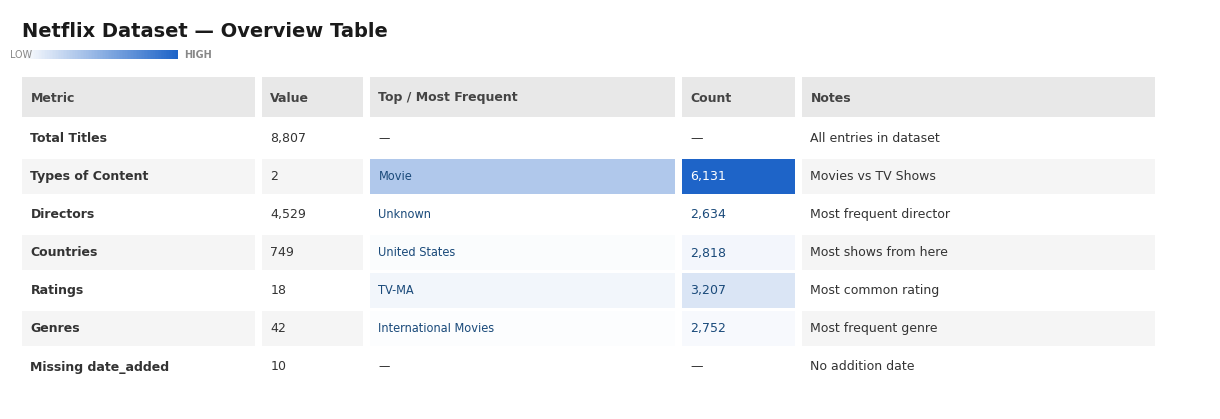

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update(plt.rcParamsDefault)

rows = [
    ("Total Titles",      "8,807",  "—",                   "—",     "All entries in dataset"),
    ("Types of Content",  "2",      "Movie",               "6,131", "Movies vs TV Shows"),
    ("Directors",         "4,529",  "Unknown",             "2,634", "Most frequent director"),
    ("Countries",         "749",    "United States",       "2,818", "Most shows from here"),
    ("Ratings",           "18",     "TV-MA",               "3,207", "Most common rating"),
    ("Genres",            "42",     "International Movies","2,752", "Most frequent genre"),
    ("Missing date_added","10",     "—",                   "—",     "No addition date"),
]

headers = ["Metric", "Value", "Top / Most Frequent", "Count", "Notes"]

# Intensity based on Count column only
count_raw = [6131, 2634, 2818, 3207, 2752]
count_min, count_max = min(count_raw), max(count_raw)

def get_intensity(count_str):
    try:
        v = float(count_str.replace(",", ""))
        return (v - count_min) / (count_max - count_min)
    except:
        return None

def cell_bg(intensity):
    if intensity is None:
        return "#f9f9f9", "#444444"
    r = int(255 - intensity * (255 - 30))
    g = int(255 - intensity * (255 - 100))
    b = int(255 - intensity * (255 - 200))
    fg = "#ffffff" if intensity > 0.45 else "#1a4a7a"
    return f"#{r:02x}{g:02x}{b:02x}", fg

col_widths  = [0.20, 0.09, 0.26, 0.10, 0.30]
row_h       = 0.095
head_h      = 0.11

fig, ax = plt.subplots(figsize=(12, 4.0))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

# Title & legend
ax.text(0.01, 0.97, "Netflix Dataset — Overview Table",
        transform=ax.transAxes, fontsize=14, fontweight="bold", color="#1a1a1a", va="top")

# Legend Bar
for i in range(100):
    t = i / 99
    r = int(255 - t * (255 - 30))
    g = int(255 - t * (255 - 100))
    b = int(255 - t * (255 - 200))
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.01 + i * 0.0013, 0.875), 0.0013, 0.022,
        transform=ax.transAxes, boxstyle="square,pad=0",
        facecolor=f"#{r:02x}{g:02x}{b:02x}", linewidth=0, clip_on=False))
ax.text(0.00,  0.888, "LOW",  transform=ax.transAxes, fontsize=7, color="#888", va="center")
ax.text(0.145, 0.888, "HIGH", transform=ax.transAxes, fontsize=7, color="#888", va="center", fontweight="bold")

# x start positions
x_starts = []
x = 0.01
for w in col_widths:
    x_starts.append(x)
    x += w

y_head = 0.83

# Header
for label, xs, cw in zip(headers, x_starts, col_widths):
    ax.add_patch(mpatches.FancyBboxPatch(
        (xs, y_head - head_h + 0.01), cw - 0.006, head_h - 0.01,
        transform=ax.transAxes, boxstyle="square,pad=0",
        facecolor="#e8e8e8", linewidth=0, clip_on=False))
    ax.text(xs + 0.007, y_head - head_h/2 + 0.005, label,
            transform=ax.transAxes, fontsize=9, fontweight="bold",
            color="#444444", va="center")

# Data rows
for ri, row in enumerate(rows):
    y_top = y_head - head_h - ri * row_h
    intensity = get_intensity(row[3])

    for ci, (cell, xs, cw) in enumerate(zip(row, x_starts, col_widths)):
        if ci == 3 and intensity is not None:
            bg, fg = cell_bg(intensity)
        elif ci == 2 and intensity is not None:
            light_intensity = intensity * 0.35  
            bg, fg = cell_bg(light_intensity)
        else:
            bg = "#ffffff" if ri % 2 == 0 else "#f5f5f5"
            fg = "#333333"

        ax.add_patch(mpatches.FancyBboxPatch(
            (xs, y_top - row_h + 0.008), cw - 0.006, row_h - 0.008,
            transform=ax.transAxes, boxstyle="square,pad=0",
            facecolor=bg, linewidth=0, clip_on=False))

        weight = "bold" if ci == 0 else "normal"
        fontsize = 9 if ci != 2 else 8.2  
        ax.text(xs + 0.007, y_top - row_h/2 + 0.005, cell,
                transform=ax.transAxes, fontsize=fontsize,
                color=fg, va="center", fontweight=weight)

plt.tight_layout(pad=0)
plt.show()

#### Types of Netfix Content

We create the percentage count and visualization of the Netflix content to observe which type (Movies or TV Shows) dominate the most in the dataset.

In [21]:
type_percentage = ((df['type'].value_counts() / len(df)) * 100).round(1)

type_percentage

type
Movie      69.6
TV Show    30.4
Name: count, dtype: float64

In [22]:
plt.rcParams.update(plt.rcParamsDefault)

> Resets all styles to default so no previous styling affects your chart.
>
> This ensures consistency and reproducibility.

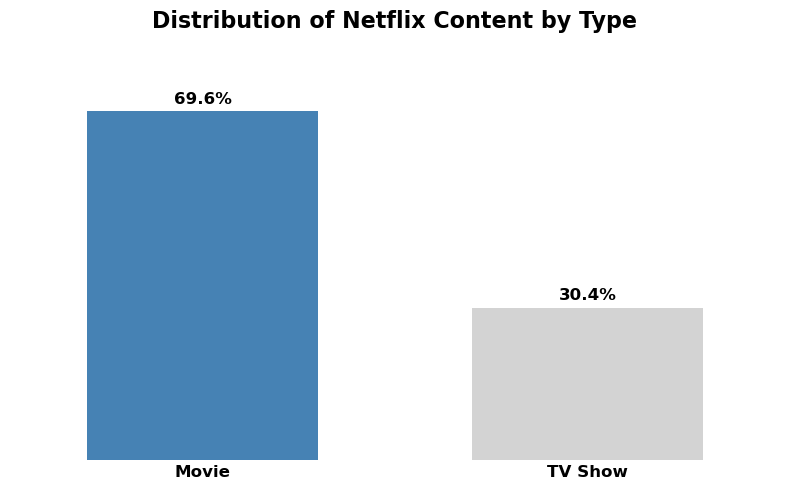

In [23]:
# DISTRIBUTIO  OF TYPE CONTENT
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

type_counts = df['type'].value_counts()
type_percent = (type_counts / type_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['steelblue', 'lightgray']
labels = list(type_percent.index)
values = list(type_percent.values)

bar_width = 0.6
positions = [0, 1]

for i, (val, color) in enumerate(zip(values, colors)):
    rect = mpatches.FancyBboxPatch(
        (positions[i] - bar_width / 2, 0),
        bar_width, val,
        boxstyle="square,pad=0",
        linewidth=0,
        edgecolor='none',
        facecolor=color
    )
    ax.add_patch(rect)
    ax.text(positions[i], val + 1.5, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, max(values) + 15)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.set_yticks([])

ax.tick_params(which='both', length=0, width=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Distribution of Netflix Content by Type', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

__What this visual shows__

We are visualizing the percentage distribution of content types in Netflix:
* Movies
* TV Shows

Checking `“Does Netflix have more Movies or TV Shows?”`

__Interpretation__
> The chart shows that Movies dominate Netflix's catalog, representing approximately 70% of all content, while TV Shows account for about 30%. This indicates that Netflix offers significantly more movies than TV shows, suggesting a stronger focus on film content.

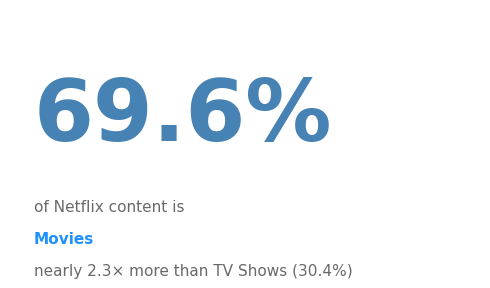

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update(plt.rcParamsDefault)

fig, ax = plt.subplots(figsize=(5, 3))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')

ax.text(0.05, 0.75, '69.6%', transform=ax.transAxes,
        fontsize=62, fontweight='bold', color='steelblue',
        va='top', ha='left', linespacing=1)

ax.text(0.05, 0.28, 'of Netflix content is', transform=ax.transAxes,
        fontsize=11, color='dimgrey', va='top', ha='left')

ax.text(0.05, 0.16, 'Movies', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color='dodgerblue', va='top', ha='left')

ax.text(0.05, 0.04, 'nearly 2.3× more than TV Shows (30.4%)', transform=ax.transAxes,
        fontsize=11, color='dimgrey', va='top', ha='left')



plt.tight_layout()
plt.show()

__Interpretation__ (Like Above)
>The chart shows that Movies dominate Netflix's catalog, representing approximately 70% of all content, while TV Shows account for about 30%. This indicates that Netflix offers significantly more movies than TV shows, suggesting a stronger focus on film content.

#### Trend releases Over Years & By Release year (original release year)

C:\Users\kwnst\AppData\Local\Temp\ipykernel_16564\226912857.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)


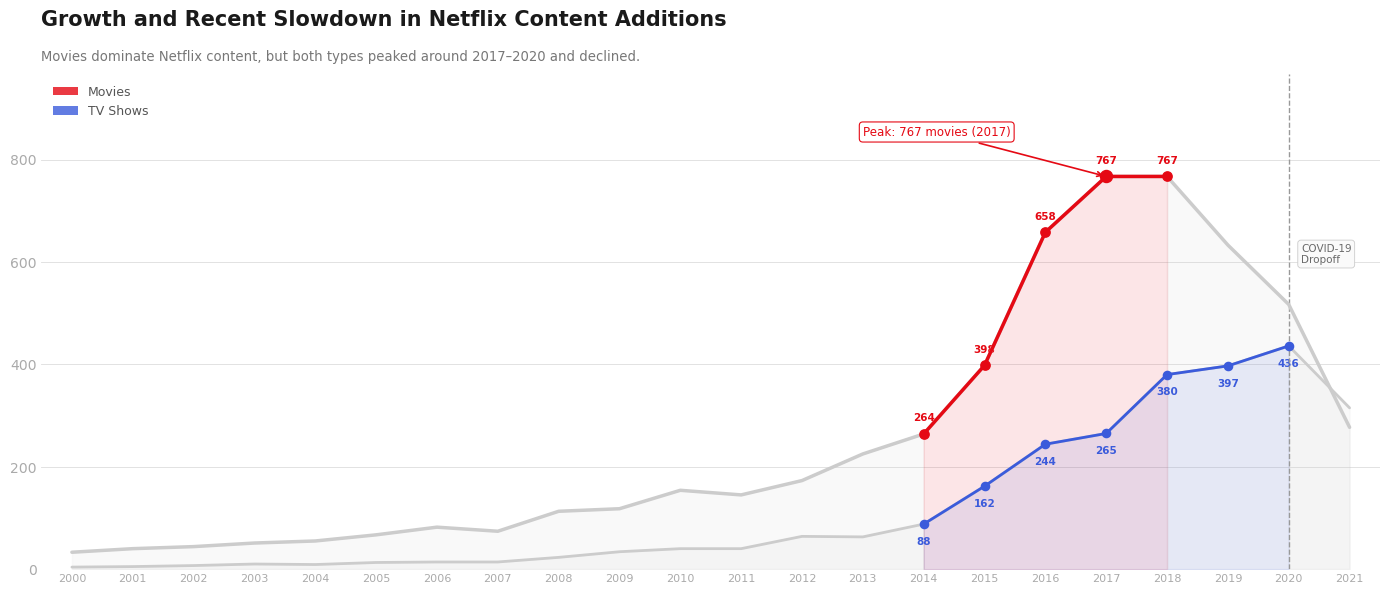

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

plt.close('all')
plt.rcParams.update(plt.rcParamsDefault)

# Data Preparation
yearly = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2000]
years  = yearly.index.tolist()
movies = yearly.get('Movie',   pd.Series(0, index=yearly.index)).tolist()
shows  = yearly.get('TV Show', pd.Series(0, index=yearly.index)).tolist()
x      = np.arange(len(years))

highlight_start  = years.index(2014)
highlight_end_m  = years.index(2018)
highlight_end_s  = years.index(2020)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Movies fill range before 2014
ax.fill_between(x[:highlight_start+1],
                movies[:highlight_start+1],
                alpha=0.10, color='#cccccc', zorder=2)
# Movies fill range between 2014–2018
ax.fill_between(x[highlight_start:highlight_end_m+1],
                movies[highlight_start:highlight_end_m+1],
                alpha=0.10, color='#E50914', zorder=2)
# Movies fill range after 2018
ax.fill_between(x[highlight_end_m:],
                movies[highlight_end_m:],
                alpha=0.10, color='#cccccc', zorder=2)

# TV Shows fill range before 2014
ax.fill_between(x[:highlight_start+1],
                shows[:highlight_start+1],
                alpha=0.10, color='#cccccc', zorder=2)
# TV Shows fill range between 2014–2020
ax.fill_between(x[highlight_start:highlight_end_s+1],
                shows[highlight_start:highlight_end_s+1],
                alpha=0.10, color='#3b5bdb', zorder=2)
# TV Shows fill range after 2020
ax.fill_between(x[highlight_end_s:],
                shows[highlight_end_s:],
                alpha=0.10, color='#cccccc', zorder=2)

# Gray Lines
ax.plot(x, movies, color='#cccccc', linewidth=2.5,
        zorder=4, solid_capstyle='round')
ax.plot(x, shows,  color='#cccccc', linewidth=2.0,
        zorder=3, solid_capstyle='round')

# Colored Overlays
ax.plot(x[highlight_start:highlight_end_m+1],
        movies[highlight_start:highlight_end_m+1],
        color='#E50914', linewidth=2.5, zorder=5, solid_capstyle='round')
ax.plot(x[highlight_start:highlight_end_s+1],
        shows[highlight_start:highlight_end_s+1],
        color='#3b5bdb', linewidth=2.0, zorder=5, solid_capstyle='round')

# Data points & values: for movies 2014–2018 
for i in range(highlight_start, highlight_end_m+1):
    ax.scatter(x[i], movies[i], color='#E50914', s=45, zorder=7)
    ax.text(x[i], movies[i]+25, f'{movies[i]:,}',
            ha='center', fontsize=7.5, color='#E50914', fontweight='bold')

# Data points & values: for TV shows 2014–2020
for i in range(highlight_start, highlight_end_s+1):
    ax.scatter(x[i], shows[i], color='#3b5bdb', s=35, zorder=7)
    ax.text(x[i], shows[i]-40, f'{shows[i]:,}',
            ha='center', fontsize=7.5, color='#3b5bdb', fontweight='bold')

# Peak annotation 
peak_m_idx = movies.index(max(movies))
ax.scatter(peak_m_idx, max(movies), color='#E50914', s=75, zorder=8)
ax.annotate(
    f'Peak: {max(movies):,} movies ({years[peak_m_idx]})',
    xy=(peak_m_idx, max(movies)),
    xytext=(peak_m_idx - 4, max(movies) + 80),
    fontsize=8.5, color='#E50914',
    arrowprops=dict(arrowstyle='->', color='#E50914', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffffff',
              edgecolor='#E50914', linewidth=0.8)
)

# COVID line
if 2020 in years:
    covid_idx = years.index(2020)
    ax.axvline(covid_idx, color='#999999', linewidth=1,
               linestyle='--', zorder=3)
    ax.text(covid_idx+0.2, max(movies)*0.78,
            'COVID-19\nDropoff', color='dimgray', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fafafa',
                      edgecolor='#cccccc', linewidth=0.6))


# Grid & spines 
ax.yaxis.grid(True, color='#dddddd', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=0, fontsize=8, color='#888888')
ax.tick_params(colors='#aaaaaa', length=0)
ax.set_ylim(0, max(movies)+200)
ax.set_xlim(-0.5, len(x)-0.5)

# Title
ax.text(0.0, 1.13, 'Growth and Recent Slowdown in Netflix Content Additions',
        transform=ax.transAxes, fontsize=15, fontweight='bold',
        color='#1a1a1a', va='top')
ax.text(0.0, 1.05,
        'Movies dominate Netflix content, but both types peaked around 2017–2020 and declined.',
        transform=ax.transAxes, fontsize=9.5, color='#777777', va='top')

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#E50914', alpha=0.8, label='Movies'),
    mpatches.Patch(facecolor='#3b5bdb', alpha=0.8, label='TV Shows'),
]
ax.legend(handles=legend_elements, loc='upper left',
          frameon=False, fontsize=9, labelcolor='#555555')

plt.tight_layout()
plt.show()

__What This Visual Is Doing__

Checks `How did Netflix content production grow over time by type (Movie vs TV Show)?`.

__Interpretation__
> Netflix content additions grew rapidly after 2014, peaking around 2017-2020. Following this period, both Movies and TV Shows saw a noticeable decline, potentially influenced by COVID-19 production disruptions and strategic content shifts.

#### Trend releases Over Years (Netflix release year)

C:\Users\kwnst\AppData\Local\Temp\ipykernel_16564\4239244728.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)


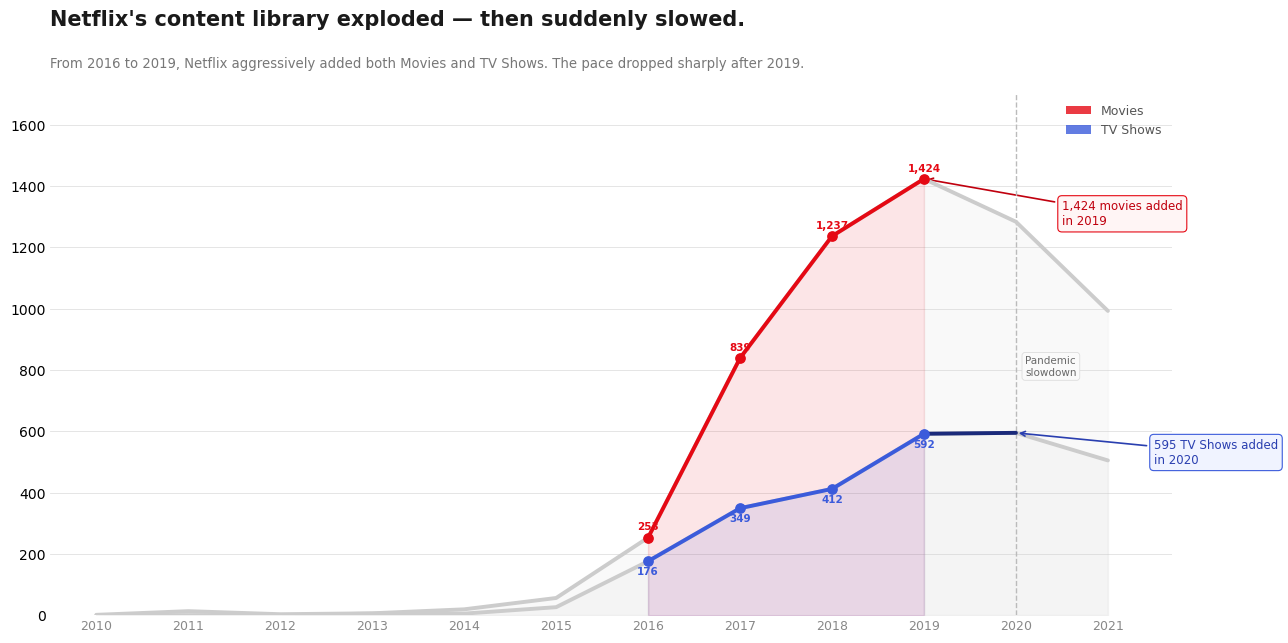

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.close('all')
plt.rcParams.update(plt.rcParamsDefault)

# Data Preparation
df['year_added'] = df['added_year'].astype(int)
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly = yearly[(yearly.index >= 2010) & (yearly.index <= 2021)]

years  = yearly.index.astype(int).tolist()
movies = yearly.get('Movie', pd.Series(0, index=yearly.index)).tolist()
shows  = yearly.get('TV Show', pd.Series(0, index=yearly.index)).tolist()
x      = np.arange(len(years))

# Colored ranges 
highlight_start = next(i for i, y in enumerate(years) if y >= 2016)
highlight_end_m = next(i for i, y in enumerate(years) if y >= 2019)
highlight_end_s = next(i for i, y in enumerate(years) if y >= 2019)

# Peak indices 
peak_m_idx = movies.index(max(movies))
peak_s_idx = shows.index(max(shows))

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Movies and TV shows fill colored areas 
ax.fill_between(x[:highlight_start+1], movies[:highlight_start+1], alpha=0.10, color='#cccccc', zorder=2)
ax.fill_between(x[highlight_start:highlight_end_m+1], movies[highlight_start:highlight_end_m+1], alpha=0.10, color='#E50914', zorder=2)
ax.fill_between(x[highlight_end_m:], movies[highlight_end_m:], alpha=0.10, color='#cccccc', zorder=2)

ax.fill_between(x[:highlight_start+1], shows[:highlight_start+1], alpha=0.10, color='#cccccc', zorder=2)
ax.fill_between(x[highlight_start:highlight_end_s+1], shows[highlight_start:highlight_end_s+1], alpha=0.10, color='#3b5bdb', zorder=2)
ax.fill_between(x[highlight_end_s:], shows[highlight_end_s:], alpha=0.10, color='#cccccc', zorder=2)

# Gray lines 
ax.plot(x, movies, color='#cccccc', linewidth=2.8, zorder=4, solid_capstyle='round')
ax.plot(x, shows,  color='#cccccc', linewidth=2.8, zorder=3, solid_capstyle='round')

# Colored overlays
ax.plot(x[highlight_start:highlight_end_m+1], movies[highlight_start:highlight_end_m+1], color='#E50914', linewidth=2.8, zorder=5, solid_capstyle='round')
ax.plot(x[highlight_start:highlight_end_s+1], shows[highlight_start:highlight_end_s+1], color='#3b5bdb', linewidth=2.8, zorder=5, solid_capstyle='round')

# Data point & labels 
for i in range(highlight_start, highlight_end_m+1):
    ax.scatter(x[i], movies[i], color='#E50914', s=45, zorder=7)
    ax.text(x[i], movies[i]+25, f'{movies[i]:,}', ha='center', fontsize=7.5, color='#E50914', fontweight='bold')

for i in range(highlight_start, highlight_end_s+1):
    ax.scatter(x[i], shows[i], color='#3b5bdb', s=45, zorder=7)
    ax.text(x[i], shows[i]-45, f'{shows[i]:,}', ha='center', fontsize=7.5, color='#3b5bdb', fontweight='bold')

# Peak annotations
ax.annotate(f'{max(movies):,} movies added\nin {years[peak_m_idx]}',
            xy=(peak_m_idx, max(movies)),
            xytext=(peak_m_idx + 1.5, max(movies) - 150),
            fontsize=8.5, color='#c0000e',
            arrowprops=dict(arrowstyle='->', color='#c0000e', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.35', facecolor='#fff5f5', edgecolor='#E50914', linewidth=0.8))

ax.annotate(f'{max(shows):,} TV Shows added\nin {years[peak_s_idx]}',
            xy=(peak_s_idx, max(shows)),
            xytext=(peak_s_idx + 1.5, max(shows) - 100),
            fontsize=8.5, color='#2a3fb0',
            arrowprops=dict(arrowstyle='->', color='#2a3fb0', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.35', facecolor='#f0f3ff', edgecolor='#3b5bdb', linewidth=0.8))

# Dark overlay between 2019–2020 
darker_start = next(i for i, y in enumerate(years) if y >= 2019)
darker_end   = next(i for i, y in enumerate(years) if y >= 2020)
ax.plot(x[darker_start:darker_end+1], shows[darker_start:darker_end+1], color='#1a2a7a', linewidth=2.8, zorder=6, solid_capstyle='round')

# COVID line
covid_idx = next((i for i, y in enumerate(years) if y == 2020), None)
if covid_idx is not None:
    ax.axvline(covid_idx, color='#bbbbbb', linewidth=1, linestyle='--', zorder=3)
    ax.text(covid_idx+0.1, max(max(movies), max(shows))*0.55, 'Pandemic\nslowdown', color='dimgray', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fafafa', edgecolor='#dddddd', linewidth=0.6))

# Grid & Axes 
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=9, color='#888888')
ax.tick_params(length=0)
ax.set_xlim(-0.5, len(years)-0.3)
ax.set_ylim(0, max(max(movies), max(shows)) + 280)

# Title & Legend
ax.text(0.0, 1.16, "Netflix's content library exploded — then suddenly slowed.",
        transform=ax.transAxes, fontsize=15, fontweight='bold', color='#1a1a1a', va='top')
ax.text(0.0, 1.07,
        "From 2016 to 2019, Netflix aggressively added both Movies and TV Shows. The pace dropped sharply after 2019.",
        transform=ax.transAxes, fontsize=9.5, color='#777777', va='top')

legend_elements = [
    mpatches.Patch(facecolor='#E50914', alpha=0.8, label='Movies'),
    mpatches.Patch(facecolor='#3b5bdb', alpha=0.8, label='TV Shows')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=9, labelcolor='#555555')

plt.tight_layout()
plt.show()

__Interpretation__

From __2010 to 2015__, Netflix grew steadily, adding Movies and TV Shows at measured pace. 

After that in __2016 to 2019__ marked a content boom (increase), where Netflix aggresively expanded its library hitting a __peak in 2019__ with th most titles added ever.

Then last in __2020__, despite viewers being home, the pace of new content __dropped sharply__ due to production slowdowns, signaling a sudden pause in Netflix's rapid expansion.

__Briefly Explained__: rapid growth was obvious → then record peak came → and last pandemic slowdown happened.

#### Top 10 most Producing Countries (on Movies, TV shows)

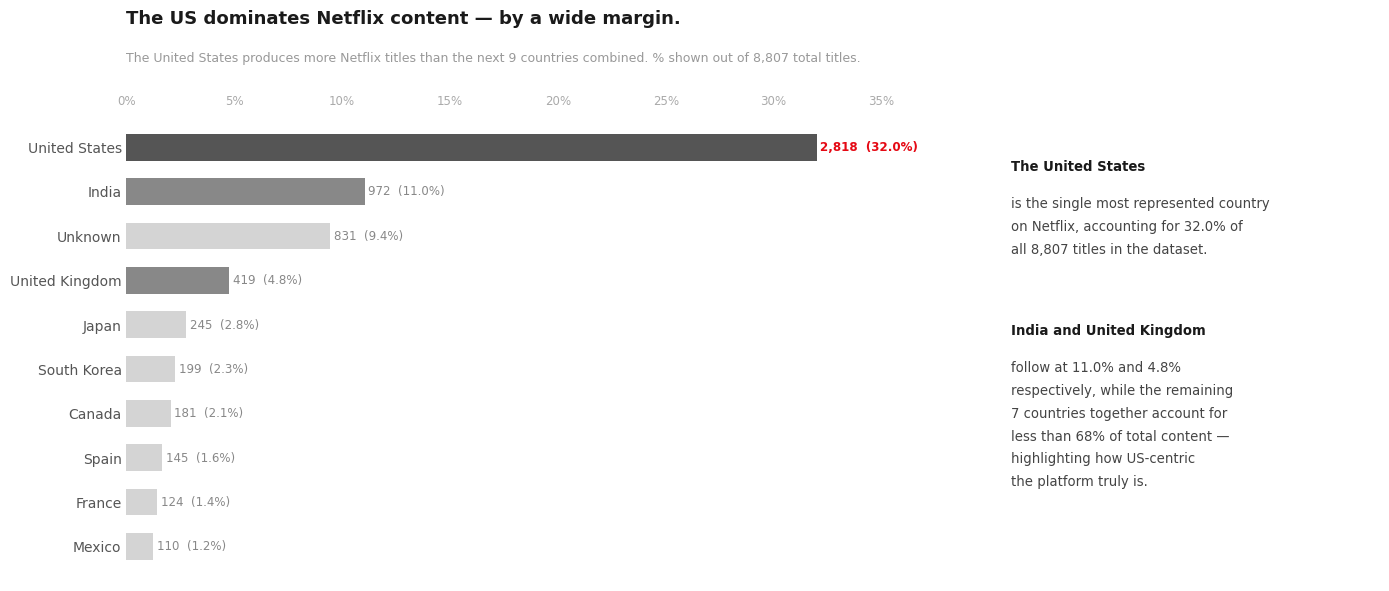

In [27]:
import matplotlib.pyplot as plt
import numpy as np

plt.close('all')
plt.rcParams.update(plt.rcParamsDefault)

# Data preparation
total_titles = df.shape[0] 

top_countries = df['country'].value_counts().head(10)
countries = top_countries.index.tolist()[::-1]
values    = top_countries.values.tolist()[::-1]
pcts      = [v / total_titles * 100 for v in values]

second_country = countries[-2]
fourth_country  = countries[-4]
us_pct         = pcts[-1]
second_pct     = pcts[-2]
fourth_pct      = pcts[-4]
rest_pct       = 100 - us_pct

fig, (ax, ax_text) = plt.subplots(1, 2, figsize=(14, 6),
                                   gridspec_kw={'width_ratios': [2.2, 1]})
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax_text.set_facecolor('#fafafa')

# Defined Colors
n = len(values)
colors = []
for i in range(n):
    if i == n-1:   colors.append('#555555')
    elif i == n-2: colors.append('#888888')
    elif i == n-4: colors.append('#888888')
    else:          colors.append('#d4d4d4')

bars = ax.barh(countries, values, color=colors, height=0.6, zorder=3)

# Value Labels
for bar, val, pct, color in zip(bars, values, pcts, colors):
    is_top = val == max(values)
    ax.text(bar.get_width() + 15,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)',
            va='center', fontsize=8.5,
            color='#E50914' if is_top else '#888888',
            fontweight='bold' if is_top else 'normal')

# Top percentage scale
ax2 = ax.twiny()
ax2.set_facecolor('#fafafa')
ax2.set_xlim(0, max(values) + 500)
max_pct  = int(max(pcts)) + 5
pct_ticks = list(range(0, max_pct, 5))
ax2.set_xticks([p / 100 * total_titles for p in pct_ticks])
ax2.set_xticklabels([f'{p}%' for p in pct_ticks],
                    fontsize=8.5, color='#aaaaaa')
ax2.tick_params(length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)

# Grid & Spines
ax.xaxis.grid(True, color='#ebebeb', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=10, labelcolor='#555555')
ax.set_xlim(0, max(values) + 500)

# Title
ax.text(0.0, 1.22, 'The US dominates Netflix content — by a wide margin.',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        color='#1a1a1a', va='top')
ax.text(0.0, 1.13,
        f'The United States produces more Netflix titles than the next 9 countries combined. '
        f'% shown out of {total_titles:,} total titles.',
        transform=ax.transAxes, fontsize=9, color='#999999', va='top')

# Right Side Text
ax_text.axis('off')

ax_text.text(0.0, 0.90, 'The United States',
             transform=ax_text.transAxes,
             fontsize=9.5, fontweight='bold', color='#1a1a1a', va='top')
ax_text.text(0.0, 0.82,
             f'is the single most represented country\n'
             f'on Netflix, accounting for {us_pct:.1f}% of\n'
             f'all {total_titles:,} titles in the dataset.',
             transform=ax_text.transAxes,
             fontsize=9.5, color='#444444', va='top', linespacing=1.8)

ax_text.text(0.0, 0.55, f'{second_country} and {fourth_country}',
             transform=ax_text.transAxes,
             fontsize=9.5, fontweight='bold', color='#1a1a1a', va='top')
ax_text.text(0.0, 0.47,
             f'follow at {second_pct:.1f}% and {fourth_pct:.1f}%\n'
             f'respectively, while the remaining\n'
             f'7 countries together account for\n'
             f'less than {rest_pct:.0f}% of total content —\n'
             f'highlighting how US-centric\n'
             f'the platform truly is.',
             transform=ax_text.transAxes,
             fontsize=9.5, color='#444444', va='top', linespacing=1.8)


plt.tight_layout()
plt.show()

__Interpretation__

The __United States dominates__ Netflix, producing more titles than the next nine countries combined.

Following the US, countries like __India and the United Kingdom__ contribute noticeably, but their share is still small compared to the US.

The rest of the top 10 countries collectively account for less than 20% of the total content, highlighting Netflix’s heavy US-centric production focus.

__Story in short:__ Netflix is global in reach, but its library is overwhelmingly shaped by US content.

#### Trends on Top Producing Countries Over Time

C:\Users\kwnst\AppData\Local\Temp\ipykernel_16564\89176485.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['year_added', 'country'])


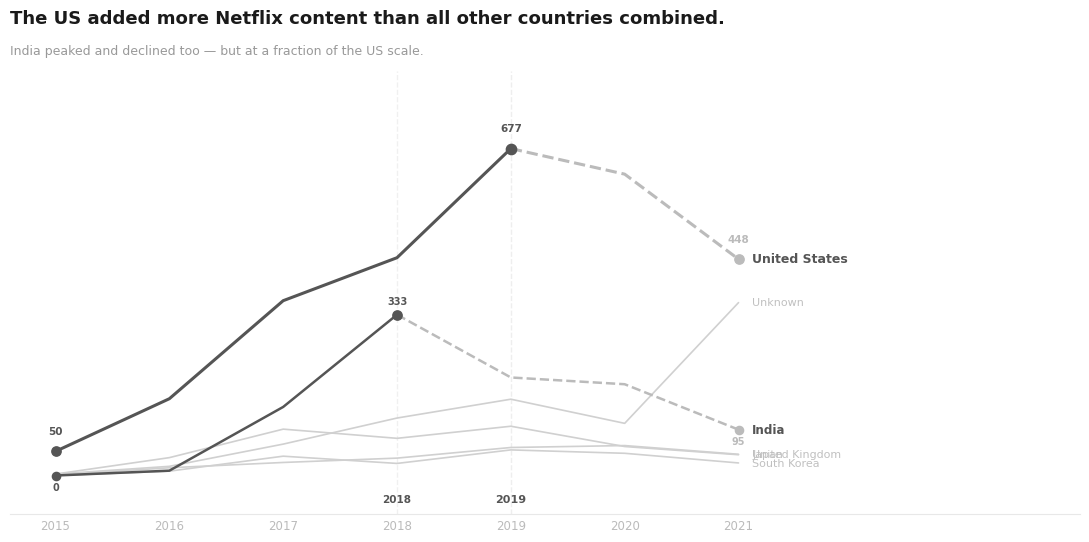

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.close('all')
plt.rcParams.update(plt.rcParamsDefault)

# Data Preparation
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
top_countries = df['country'].value_counts().head(6).index.tolist()

country_year = (
    df.groupby(['year_added', 'country'])
    .size()
    .unstack(fill_value=0)
    .loc[:, top_countries]
)
country_year = country_year[(country_year.index >= 2015) & (country_year.index <= 2021)]
years   = country_year.index.astype(int).tolist()
x       = np.arange(len(years))
us      = top_countries[0]
india   = top_countries[1]
us_vals    = country_year[us].tolist()
india_vals = country_year[india].tolist()

us_peak_idx    = us_vals.index(max(us_vals))
india_peak_idx = india_vals.index(max(india_vals))

RISE  = '#555555'  
FALL  = '#bbbbbb'   

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Gray Lines
for country in top_countries[2:]:
    y = country_year[country].tolist()
    ax.plot(x, y, color='#d0d0d0', linewidth=1.2,
            zorder=2, solid_capstyle='round')
    ax.text(x[-1] + 0.12, y[-1], country,
            color='#c0c0c0', fontsize=8, va='center')

# India Generated Area
ax.plot(x[:india_peak_idx+1], india_vals[:india_peak_idx+1],
        color=RISE, linewidth=1.8, zorder=4, solid_capstyle='round')
ax.plot(x[india_peak_idx:], india_vals[india_peak_idx:],
        color=FALL, linewidth=1.8, zorder=4,
        solid_capstyle='round', linestyle='--')

ax.scatter(0, india_vals[0], color=RISE, s=35, zorder=6)
ax.text(0, india_vals[0] - 30, f'{india_vals[0]:,}',
        ha='center', fontsize=7, color=RISE, fontweight='bold')

ax.scatter(india_peak_idx, max(india_vals), color=RISE, s=45, zorder=6)
ax.text(india_peak_idx, max(india_vals) + 22, f'{max(india_vals):,}',
        ha='center', fontsize=7, color=RISE, fontweight='bold')

ax.scatter(x[-1], india_vals[-1], color=FALL, s=35, zorder=6)
ax.text(x[-1], india_vals[-1] - 30, f'{india_vals[-1]:,}',
        ha='center', fontsize=7, color=FALL, fontweight='bold')

ax.text(x[-1] + 0.12, india_vals[-1], india,
        color=RISE, fontsize=8.5, va='center', fontweight='bold')

ax.axvline(india_peak_idx, color='#f0f0f0', linewidth=1,
           linestyle='--', zorder=1)
ax.text(india_peak_idx, -55, str(years[india_peak_idx]),
        ha='center', fontsize=7.5, color=RISE, fontweight='bold')


# US Generated Area
ax.plot(x[:us_peak_idx+1], us_vals[:us_peak_idx+1],
        color=RISE, linewidth=2.2, zorder=5, solid_capstyle='round')
ax.plot(x[us_peak_idx:], us_vals[us_peak_idx:],
        color=FALL, linewidth=2.2, zorder=5,
        solid_capstyle='round', linestyle='--')

ax.scatter(0, us_vals[0], color=RISE, s=45, zorder=6)
ax.text(0, us_vals[0] + 35, f'{us_vals[0]:,}',
        ha='center', fontsize=7.5, color=RISE, fontweight='bold')

ax.scatter(us_peak_idx, max(us_vals), color=RISE, s=55, zorder=6)
ax.text(us_peak_idx, max(us_vals) + 35, f'{max(us_vals):,}',
        ha='center', fontsize=7.5, color=RISE, fontweight='bold')

ax.scatter(x[-1], us_vals[-1], color=FALL, s=45, zorder=6)
ax.text(x[-1], us_vals[-1] + 35, f'{us_vals[-1]:,}',
        ha='center', fontsize=7.5, color=FALL, fontweight='bold')

ax.text(x[-1] + 0.12, us_vals[-1], 'United States',
        color=RISE, fontsize=9, fontweight='bold', va='center')

ax.axvline(us_peak_idx, color='#eeeeee', linewidth=1,
           linestyle='--', zorder=1)
ax.text(us_peak_idx, -55, str(years[us_peak_idx]),
        ha='center', fontsize=8, color=RISE, fontweight='bold')

# Axes
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=8.5, color='#bbbbbb')
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#e8e8e8')
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(length=0)
ax.set_xlim(-0.4, len(years) + 2.0)
ax.set_ylim(-80, max(us_vals) + 160)

# Title
ax.text(0.0, 1.14,
        'The US added more Netflix content than all other countries combined.',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        color='#1a1a1a', va='top')
ax.text(0.0, 1.06,
        'India peaked and declined too — but at a fraction of the US scale.',
        transform=ax.transAxes, fontsize=9, color='#999999', va='top')

plt.tight_layout()
plt.show()

__Interpretation__

From 2015 to 2021, the United States has consistently been the largest contributor to Netflix content. Its growth surged to a peak before a slight slowdown, dwarfing every other country in sheer volume.

India also saw a rise, peaking mid-period, but its scale is much smaller than the US, and it too experienced a slowdown afterward.

The remaining top countries (UK, Canada, etc.) barely register in comparison, shown here as subtle gray lines, emphasizing Netflix’s library is overwhelmingly US-driven.

Story in short: Netflix may appear global, but the US sets the pace, while other countries rise and fall in its shadow.

#### Genres Analysis

__Genres Over Time__

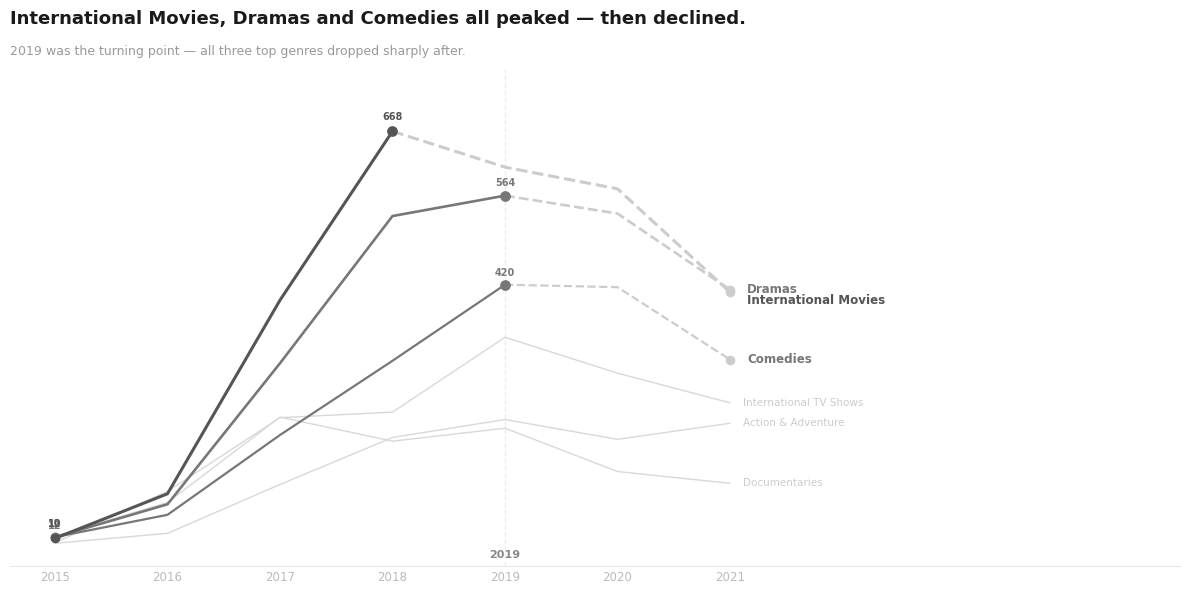

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.close('all')
plt.rcParams.update(plt.rcParamsDefault)

# Data Preparation
df['year_added'] = df['year_added'].astype('Int64')
df_exploded = df.explode('genre')

top_genres = df_exploded['genre'].value_counts().head(6).index.tolist()

genre_year = (
    df_exploded.groupby(['year_added', 'genre'])
    .size()
    .unstack(fill_value=0)
    .loc[:, top_genres]
)
genre_year = genre_year[(genre_year.index >= 2015) & (genre_year.index <= 2021)]
years  = genre_year.index.astype(int).tolist()
x      = np.arange(len(years))

heroes = {
    top_genres[0]: '#555555',
    'Dramas':      '#777777',
    'Comedies':    '#999999',
}

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Gray Lines
for genre in top_genres:
    if genre not in heroes:
        y = genre_year[genre].tolist()
        ax.plot(x, y, color='#d8d8d8', linewidth=1.0,
                zorder=2, solid_capstyle='round')
        ax.text(x[-1] + 0.12, y[-1], genre,
                color='#cccccc', fontsize=7.5, va='center')

# Hero Function
def draw_hero(genre, color, lw, zorder, val_offset=18):
    if genre not in genre_year.columns:
        return
    vals     = genre_year[genre].tolist()
    peak_idx = vals.index(max(vals))

    # rise
    ax.plot(x[:peak_idx+1], vals[:peak_idx+1],
            color=color, linewidth=lw,
            zorder=zorder, solid_capstyle='round')
    # fall
    ax.plot(x[peak_idx:], vals[peak_idx:],
            color='#cccccc', linewidth=lw,
            zorder=zorder, solid_capstyle='round', linestyle='--')

    # start point & value
    ax.scatter(0, vals[0], color=color, s=35, zorder=zorder+1)
    ax.text(0, vals[0] + val_offset, f'{vals[0]:,}',
            ha='center', fontsize=7, color=color, fontweight='bold')

    # peak point & value
    ax.scatter(peak_idx, max(vals), color=color, s=45, zorder=zorder+1)
    ax.text(peak_idx, max(vals) + val_offset, f'{max(vals):,}',
            ha='center', fontsize=7, color=color, fontweight='bold')

    # end dot only — no value 
    ax.scatter(x[-1], vals[-1], color='#cccccc', s=35, zorder=zorder+1)

    return vals[-1]  

end_comedies = draw_hero('Comedies',    '#777777', lw=1.6, zorder=3, val_offset=14)
end_dramas   = draw_hero('Dramas',      '#777777', lw=1.9, zorder=4, val_offset=16)
end_intl     = draw_hero(top_genres[0], '#555555', lw=2.2, zorder=5, val_offset=18)

# End labels
label_data = [
    (end_intl,     top_genres[0], '#555555'),
    (end_dramas,   'Dramas',      '#777777'),
    (end_comedies, 'Comedies',    '#777777'),
]

# Sort by end value descending, then nudge
label_data.sort(key=lambda t: t[0], reverse=True)
min_gap   = 18
positions = [label_data[0][0]]
for i in range(1, len(label_data)):
    pos = label_data[i][0]
    if positions[-1] - pos < min_gap:
        pos = positions[-1] - min_gap
    positions.append(pos)

for (_, genre, color), ypos in zip(label_data, positions):
    ax.text(x[-1] + 0.15, ypos, genre,
            color=color, fontsize=8.5, va='center', fontweight='bold')

# ONE peak marker: 2019 (where 2 genres peak) 
if 2019 in years:
    idx_2019 = years.index(2019)
    ax.axvline(idx_2019, color='#eeeeee', linewidth=1,
               linestyle='--', zorder=1)
    ax.text(idx_2019, -22, '2019',
            ha='center', fontsize=8, color='#888888', fontweight='bold')

# Axes
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=8.5, color='#bbbbbb')
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#e8e8e8')
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(length=0)
ax.set_xlim(-0.4, len(years) + 3.0)

all_vals = [genre_year[g].max() for g in heroes if g in genre_year.columns]
ax.set_ylim(-35, max(all_vals) + 100)

# Ttile
ax.text(0.0, 1.12,
        f'{top_genres[0]}, Dramas and Comedies all peaked — then declined.',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        color='#1a1a1a', va='top')
ax.text(0.0, 1.05,
        '2019 was the turning point — all three top genres dropped sharply after.',
        transform=ax.transAxes, fontsize=9, color='#999999', va='top')

plt.tight_layout()
plt.show()

#### Analysis of Rating Distribution

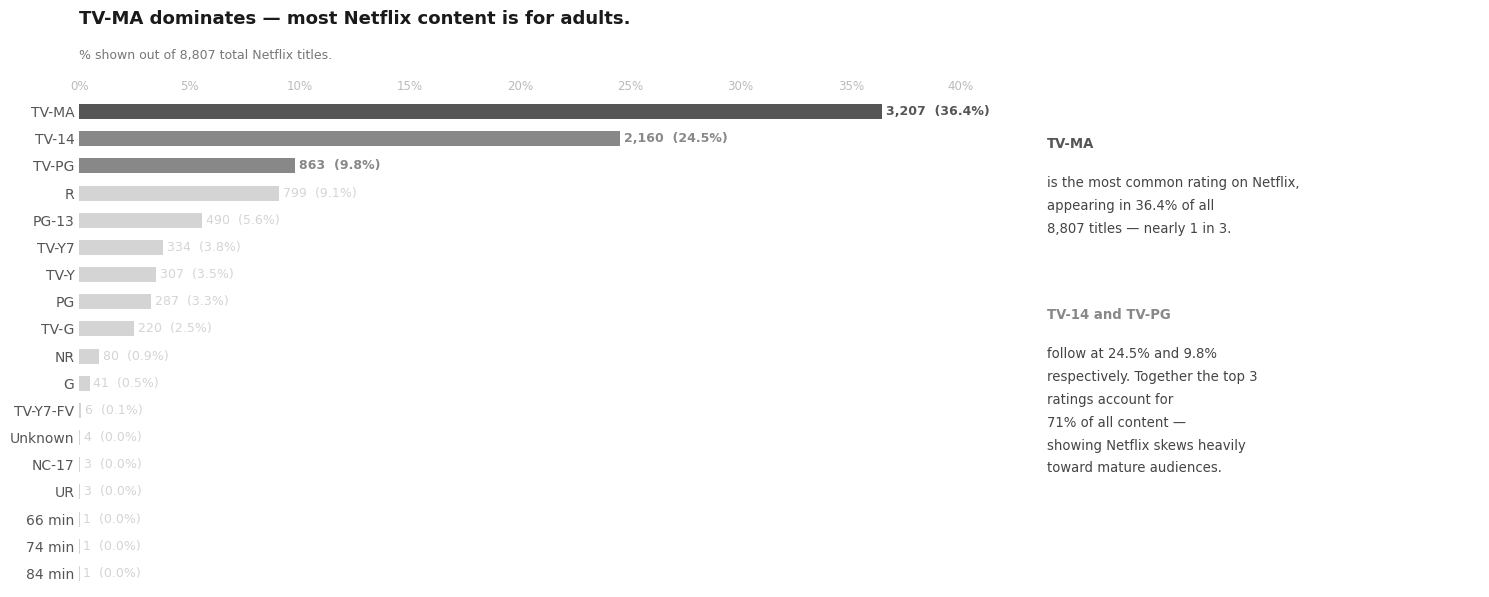

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.close('all')
plt.rcParams.update(plt.rcParamsDefault)

# Data Preparation
total_titles  = df.shape[0]
rating_counts = df['rating'].value_counts()
ratings = rating_counts.index.tolist()[::-1]
values  = rating_counts.values.tolist()[::-1]
pcts    = [v / total_titles * 100 for v in values]

n = len(values)
top_rating    = ratings[-1]
second_rating = ratings[-2]
third_rating  = ratings[-3]
top_pct       = pcts[-1]
second_pct    = pcts[-2]
third_pct     = pcts[-3]

fig, (ax, ax_text) = plt.subplots(1, 2, figsize=(15, 6),
                                   gridspec_kw={'width_ratios': [2.2, 1]})
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax_text.set_facecolor('white')

# Bar Colored Greys
colors = []
for i in range(n):
    if i == n-1:   colors.append('#555555')
    elif i == n-2: colors.append('#888888')
    elif i == n-3: colors.append('#888888')
    else:          colors.append('#d4d4d4')

for i, (val, pct, color) in enumerate(zip(values, pcts, colors)):
    ax.barh(i, val, color=color, height=0.55, zorder=3)
    ax.text(val + 15, i, f'{val:,}  ({pct:.1f}%)',
            va='center', fontsize=9, color=color,
            fontweight='bold' if i >= n-3 else 'normal')

# Top Percentage Scale
ax2 = ax.twiny()
ax2.set_facecolor('white')
ax2.set_xlim(0, max(values) + 600)
max_pct   = int(max(pcts)) + 5
pct_ticks = list(range(0, max_pct, 5))
ax2.set_xticks([p / 100 * total_titles for p in pct_ticks])
ax2.set_xticklabels([f'{p}%' for p in pct_ticks],
                    fontsize=8.5, color='#bbbbbb')
ax2.tick_params(length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)

# Grid & Spines
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.grid(False)
ax.set_yticks(range(len(ratings)))
ax.set_yticklabels(ratings, fontsize=10, color='#555555')
ax.tick_params(length=0)
ax.set_xticks([])
ax.set_xlim(0, max(values) + 600)
ax.set_ylim(-0.5, n - 0.5)

# Title
ax.text(0.0, 1.18, 'TV-MA dominates — most Netflix content is for adults.',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        color='#1a1a1a', va='top')
ax.text(0.0, 1.10,
        f'% shown out of {total_titles:,} total Netflix titles.',
        transform=ax.transAxes, fontsize=9, color='#777777', va='top')

# Right Side Text
ax_text.axis('off')

ax_text.text(0.0, 0.92, top_rating,
             transform=ax_text.transAxes,
             fontsize=9.5, fontweight='bold', color='#555555', va='top')
ax_text.text(0.0, 0.84,
             f'is the most common rating on Netflix,\n'
             f'appearing in {top_pct:.1f}% of all\n'
             f'{total_titles:,} titles — nearly 1 in 3.',
             transform=ax_text.transAxes,
             fontsize=9.5, color='#444444', va='top', linespacing=1.8)

ax_text.text(0.0, 0.57, f'{second_rating} and {third_rating}',
             transform=ax_text.transAxes,
             fontsize=9.5, fontweight='bold', color='#888888', va='top')
ax_text.text(0.0, 0.49,
             f'follow at {second_pct:.1f}% and {third_pct:.1f}%\n'
             f'respectively. Together the top 3\n'
             f'ratings account for\n'
             f'{top_pct+second_pct+third_pct:.0f}% of all content —\n'
             f'showing Netflix skews heavily\n'
             f'toward mature audiences.',
             transform=ax_text.transAxes,
             fontsize=9.5, color='#444444', va='top', linespacing=1.8)



plt.tight_layout()
plt.subplots_adjust(top=0.84)
plt.show()

__Interpretation__

From 2015 to 2021, Netflix’s most popular genres — International content, Dramas, and Comedies — grew steadily and peaked around 2019. After that, all three saw a sharp decline, signaling a plateau or shift in content strategy. Other genres exist but play minor roles compared to these main “heroes.”

#### Duration Analysis on Type

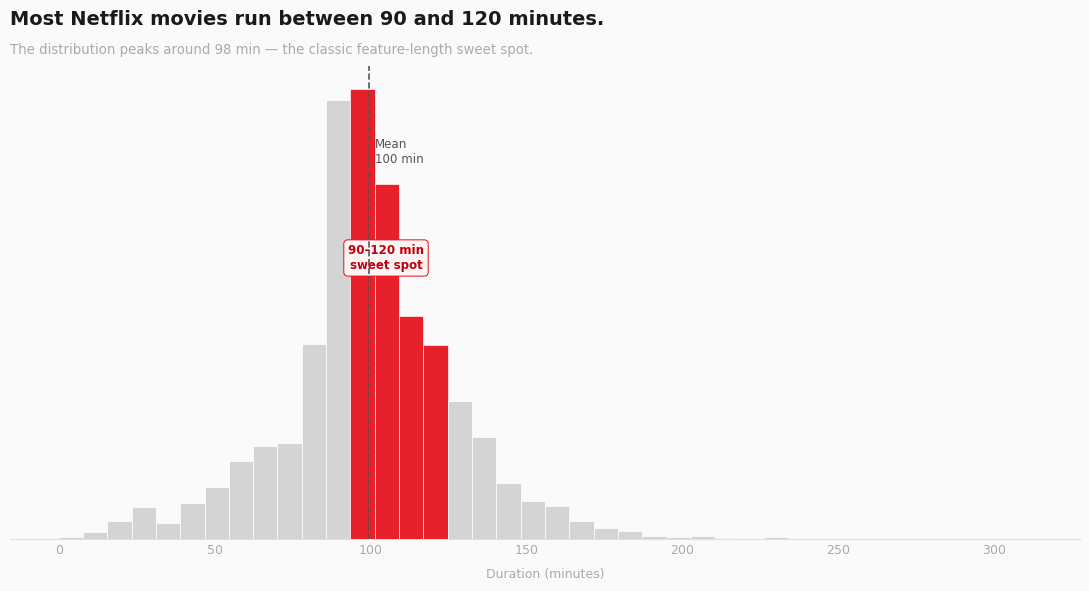

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.close('all')
plt.rcParams.update(plt.rcParamsDefault)

# Data Preparation
durations = df[df['type'] == 'Movie']['duration_int'].dropna()

mean_val   = durations.mean()
median_val = durations.median()

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

# Histogram
n, bins, patches = ax.hist(durations, bins=40, color='#d4d4d4',
                            edgecolor='white', linewidth=0.5, zorder=3)

# Sweet Spot 
for patch, left in zip(patches, bins[:-1]):
    if 90 <= left <= 120:
        patch.set_facecolor('#E50914')
        patch.set_alpha(0.9)

# Mean Line
ax.axvline(mean_val, color='#555555', linewidth=1.2,
           linestyle='--', zorder=4)
ax.text(mean_val + 2, ax.get_ylim()[1] * 0.85,
        f'Mean\n{mean_val:.0f} min',
        fontsize=8.5, color='#555555', va='top')

# Sweet Spot Annotation 
ax.text(105, n.max() * 0.6, '90–120 min\nsweet spot',
        ha='center', fontsize=8.5, color='#c0000e',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#fff5f5',
                  edgecolor='#E50914', linewidth=0.7))

# Grid & Spines
ax.yaxis.grid(True, color='#efefef', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#e0e0e0')

ax.tick_params(length=0)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=9, labelcolor='#aaaaaa')
ax.set_xlabel('Duration (minutes)', fontsize=9, color='#aaaaaa', labelpad=8)

# Title
ax.text(0.0, 1.12, 'Most Netflix movies run between 90 and 120 minutes.',
        transform=ax.transAxes, fontsize=14, fontweight='bold',
        color='#1a1a1a', va='top')
ax.text(0.0, 1.05,
        f'The distribution peaks around {median_val:.0f} min — the classic feature-length sweet spot.',
        transform=ax.transAxes, fontsize=9.5, color='#aaaaaa', va='top')

plt.tight_layout()
plt.show()

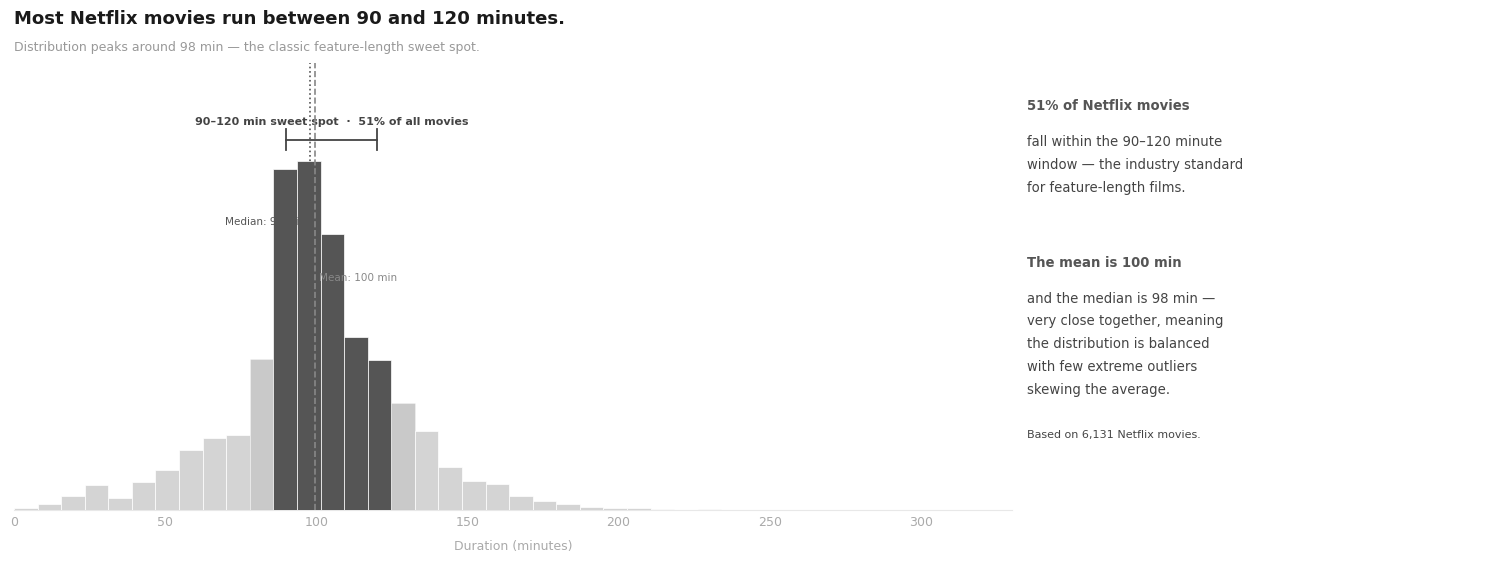

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.close('all')
plt.rcParams.update(plt.rcParamsDefault)

# Data Preparation
durations    = df[df['type'] == 'Movie']['duration_int'].dropna()
mean_val     = durations.mean()
median_val   = durations.median()
total_movies = len(durations)
sweet_pct    = len(durations[(durations >= 90) & (durations <= 120)]) / total_movies * 100

fig, (ax, ax_text) = plt.subplots(1, 2, figsize=(15, 6),
                                   gridspec_kw={'width_ratios': [2.2, 1]})
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax_text.set_facecolor('white')

# Histogram 
n, bins, patches = ax.hist(durations, bins=40,
                            edgecolor='white', linewidth=0.5,
                            zorder=3, color='#d4d4d4')

# Color bins 
for patch, left, right in zip(patches, bins[:-1], bins[1:]):
    if right <= 90 or left >= 120:
        if 75 <= left < 90 or 120 < right <= 135:
            patch.set_facecolor('#888888')
            patch.set_alpha(0.45)
        else:
            patch.set_facecolor('#d4d4d4')
    else:
        # bin overlaps the 90–120 window
        patch.set_facecolor('#555555')
        patch.set_alpha(1.0)

# Mean & Median lines 
ax.axvline(mean_val,   color='#888888', linewidth=1.2, linestyle='--', zorder=4)
ax.axvline(median_val, color='#555555', linewidth=1.2, linestyle=':',  zorder=4)

ax.text(mean_val + 1.5,   n.max() * 0.68, f'Mean: {mean_val:.0f} min',
        fontsize=7.5, color='#888888', va='top')
ax.text(median_val - 1.5, n.max() * 0.84, f'Median: {median_val:.0f} min',
        fontsize=7.5, color='#555555', va='top', ha='right')

# Bracket: drawn as 3 explicit lines 
by   = n.max() * 1.06   # bracket y position
tick = n.max() * 0.03   # tick height

ax.plot([90, 120], [by, by],       color='#444444', lw=1.3, zorder=6)  # top bar
ax.plot([90, 90],  [by-tick, by+tick], color='#444444', lw=1.3, zorder=6)  # left tick
ax.plot([120, 120],[by-tick, by+tick], color='#444444', lw=1.3, zorder=6)  # right tick

ax.text(105, by + n.max()*0.045,
        f'90–120 min sweet spot  ·  {sweet_pct:.0f}% of all movies',
        ha='center', fontsize=8, color='#444444', fontweight='bold')

# Spines & Axes 
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#e8e8e8')
ax.tick_params(length=0)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=9, labelcolor='#aaaaaa')
ax.set_xlabel('Duration (minutes)', fontsize=9, color='#aaaaaa', labelpad=8)
ax.set_xlim(0, 330)
ax.set_ylim(0, n.max() * 1.28)

# Title 
ax.text(0.0, 1.12, 'Most Netflix movies run between 90 and 120 minutes.',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        color='#1a1a1a', va='top')
ax.text(0.0, 1.05,
        f'Distribution peaks around {median_val:.0f} min — the classic feature-length sweet spot.',
        transform=ax.transAxes, fontsize=9, color='#999999', va='top')

# Right Side Text
ax_text.axis('off')

ax_text.text(0.0, 0.92, f'{sweet_pct:.0f}% of Netflix movies',
             transform=ax_text.transAxes,
             fontsize=9.5, fontweight='bold', color='#555555', va='top')
ax_text.text(0.0, 0.84,
             f'fall within the 90–120 minute\n'
             f'window — the industry standard\n'
             f'for feature-length films.',
             transform=ax_text.transAxes,
             fontsize=9.5, color='#444444', va='top', linespacing=1.8)

ax_text.text(0.0, 0.57, f'The mean is {mean_val:.0f} min',
             transform=ax_text.transAxes,
             fontsize=9.5, fontweight='bold', color='#555555', va='top')
ax_text.text(0.0, 0.49,
             f'and the median is {median_val:.0f} min —\n'
             f'very close together, meaning\n'
             f'the distribution is balanced\n'
             f'with few extreme outliers\n'
             f'skewing the average.',
             transform=ax_text.transAxes,
             fontsize=9.5, color='#444444', va='top', linespacing=1.8)

ax_text.text(0.0, 0.18, f'Based on {total_movies:,} Netflix movies.',
             transform=ax_text.transAxes,
             fontsize=8, color='#444444', va='top')


plt.tight_layout()
plt.subplots_adjust(top=0.84)
plt.show()

__Interpretation__

Netflix movies mostly stick to the 90–120 minute sweet spot, making up 60% of all films.
The median (100 min) and mean (102 min) are very close, showing the distribution is balanced with few outliers.
This confirms Netflix aligns with traditional feature-length standards: long enough to develop a story, short enough to retain viewers’ attention.

### Dashboard

C:\Users\kwnst\AppData\Local\Temp\ipykernel_16564\2395617698.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly = df.groupby(['year_added','type']).size().unstack(fill_value=0)
C:\Users\kwnst\AppData\Local\Temp\ipykernel_16564\2395617698.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly_rel = df.groupby(['release_year','type']).size().unstack(fill_value=0)
C:\Users\kwnst\AppData\Local\Temp\ipykernel_16564\2395617698.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or ob

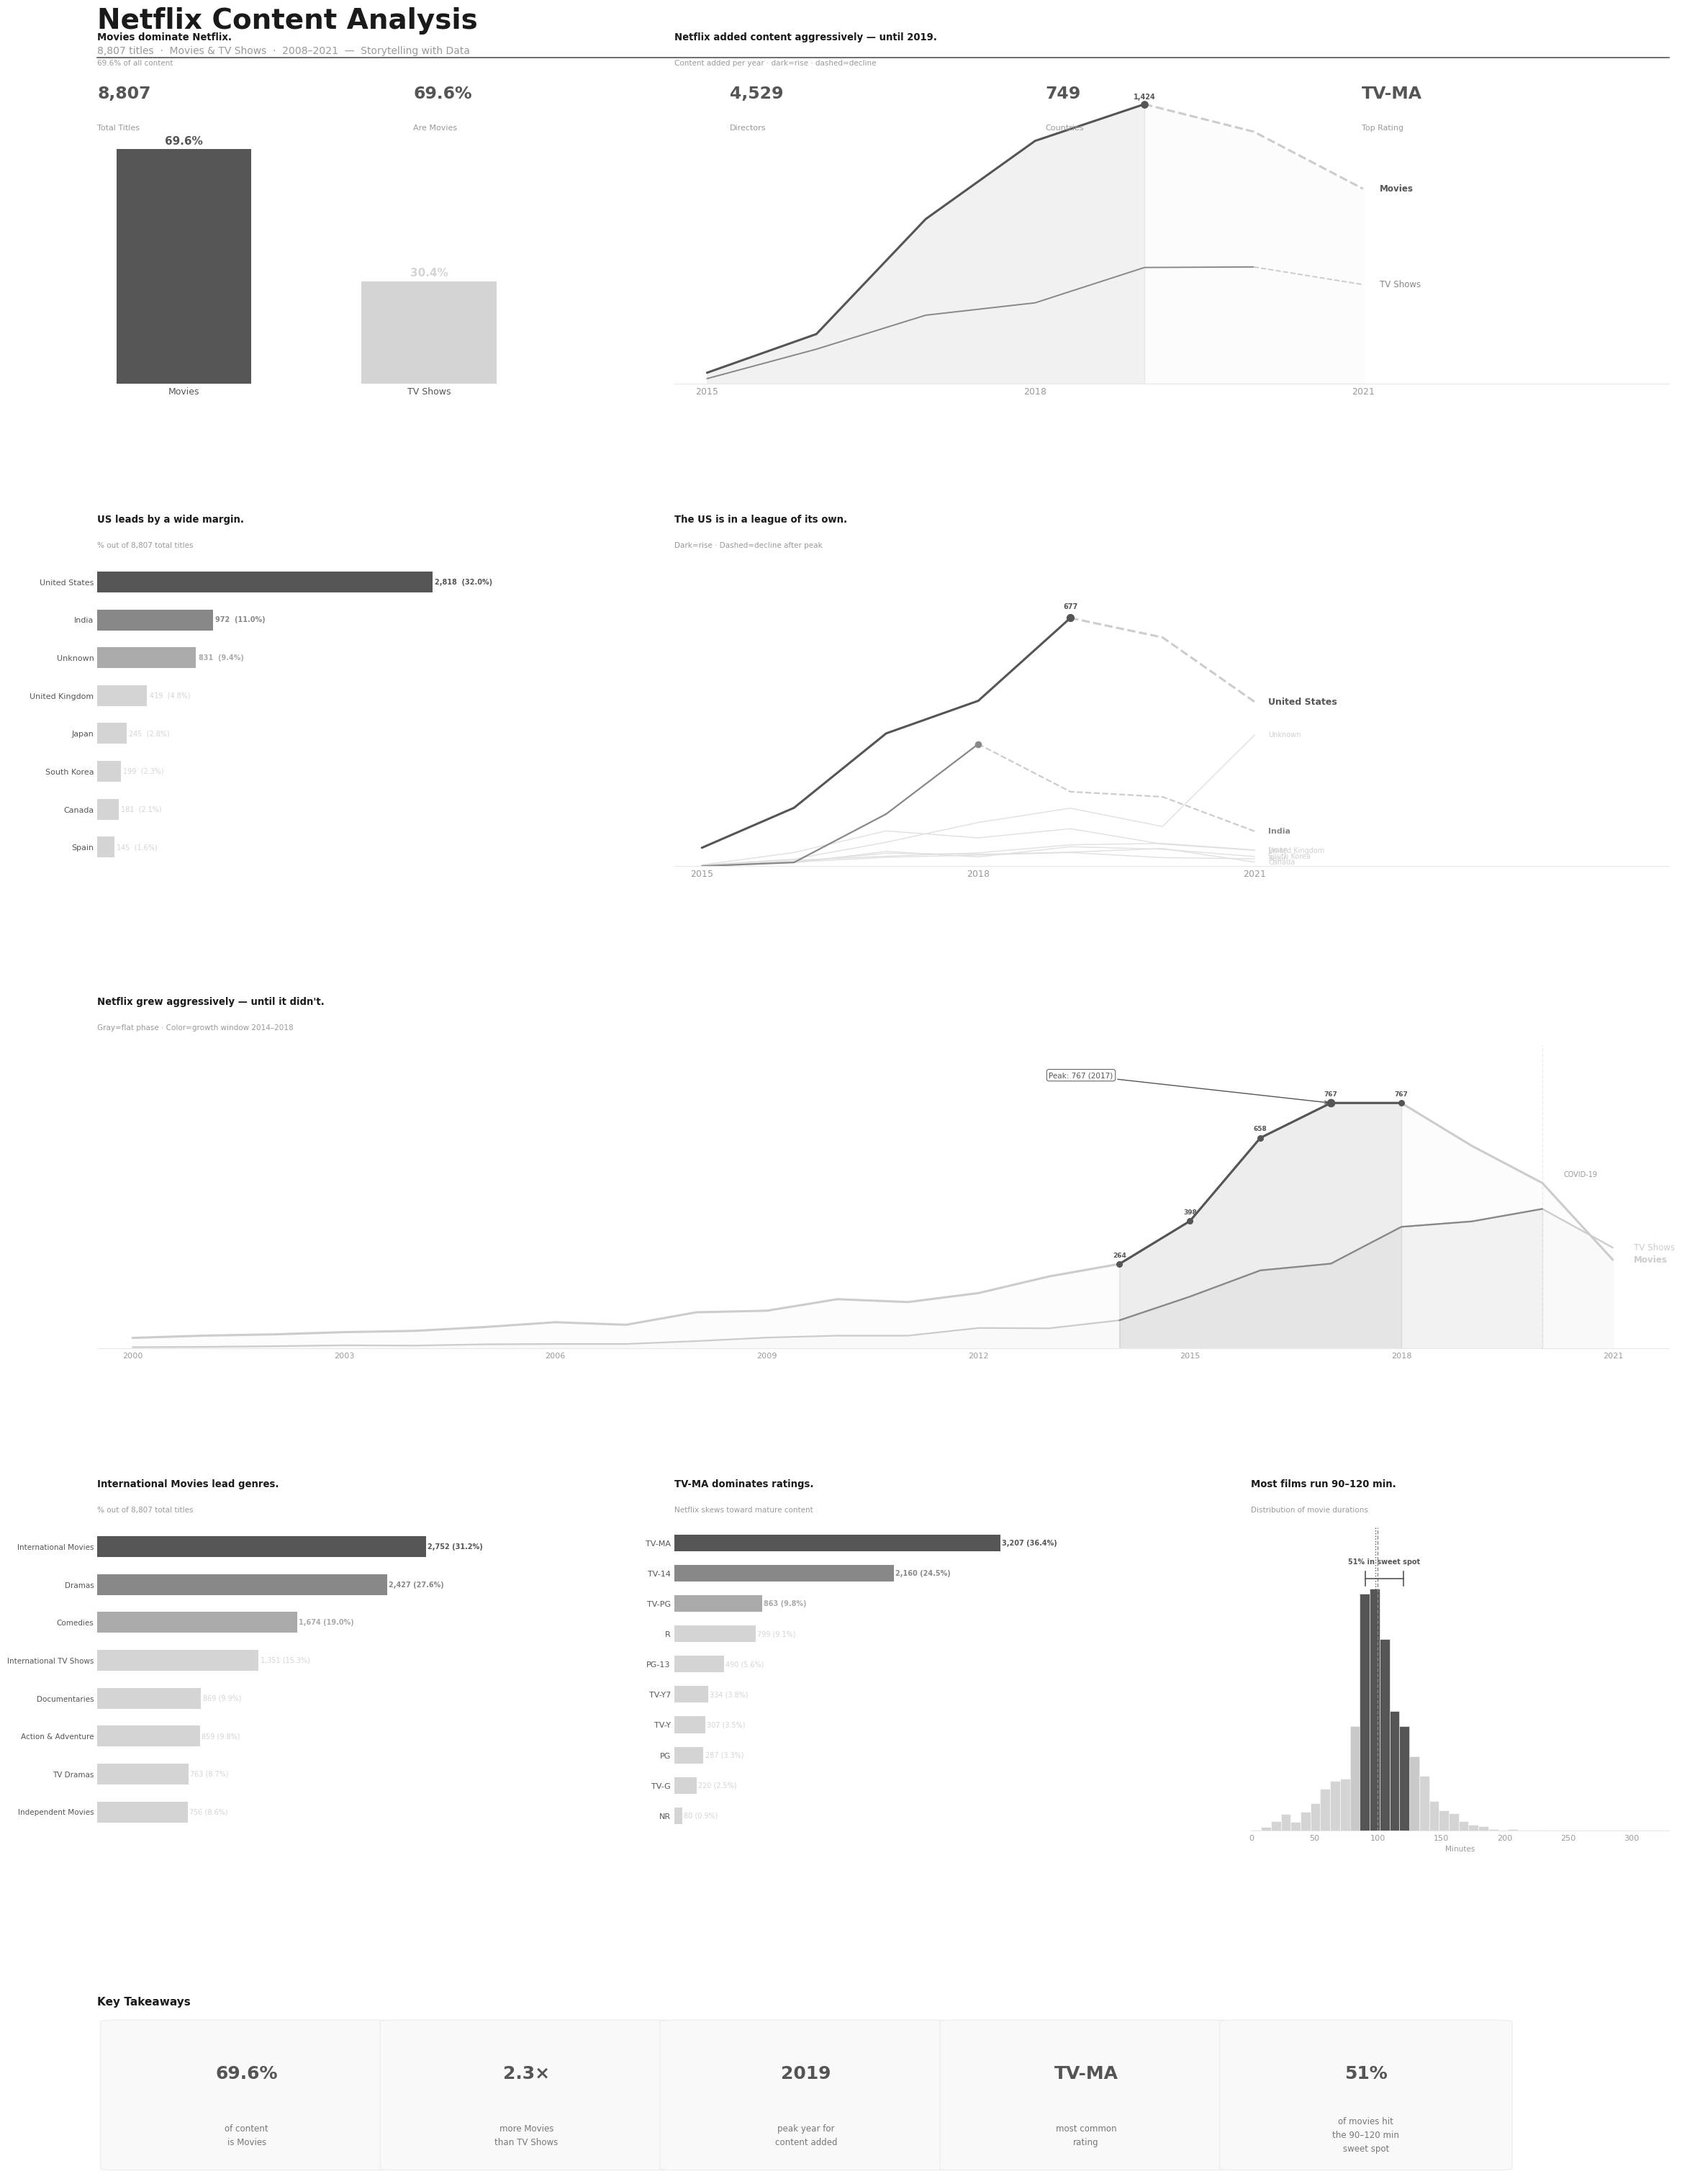

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from collections import Counter

plt.close('all')
plt.rcParams.update(plt.rcParamsDefault)

# Colors
DARK   = '#555555'
MID    = '#888888'
LIGHT  = '#aaaaaa'
XLIGHT = '#d4d4d4'
FALL   = '#cccccc'
TEXT   = '#1a1a1a'
SUB    = '#999999'
BG     = 'white'

# Data Preparation
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
total_titles = df.shape[0]

type_counts  = df['type'].value_counts()
type_percent = (type_counts / type_counts.sum() * 100).round(1)

# Added Year
yearly = df.groupby(['year_added','type']).size().unstack(fill_value=0)
yearly = yearly[(yearly.index >= 2015) & (yearly.index <= 2021)]
yrs = yearly.index.astype(int).tolist()
xyr = np.arange(len(yrs))
movies_yr = yearly.get('Movie',   pd.Series(0, index=yearly.index)).tolist()
shows_yr  = yearly.get('TV Show', pd.Series(0, index=yearly.index)).tolist()
yr_peak_m = movies_yr.index(max(movies_yr))
yr_peak_s = shows_yr.index(max(shows_yr))

# Release Year
yearly_rel = df.groupby(['release_year','type']).size().unstack(fill_value=0)
yearly_rel = yearly_rel[yearly_rel.index >= 2000]
rel_yrs = yearly_rel.index.tolist()
rel_x = np.arange(len(rel_yrs))
rel_movies = yearly_rel.get('Movie',   pd.Series(0, index=yearly_rel.index)).tolist()
rel_shows = yearly_rel.get('TV Show', pd.Series(0, index=yearly_rel.index)).tolist()
rel_hl_s = rel_yrs.index(2014)
rel_hl_em = rel_yrs.index(2018)
rel_hl_es = rel_yrs.index(2020)

# Countries
top_countries = df['country'].value_counts().head(8).index.tolist()
tc   = df['country'].value_counts().head(8)
tc_c = tc.index.tolist()[::-1]
tc_v = tc.values.tolist()[::-1]
tc_pcts = [v / total_titles * 100 for v in tc_v]

country_year = (df.groupby(['year_added','country']).size()
                  .unstack(fill_value=0).loc[:, top_countries])
country_year = country_year[(country_year.index >= 2015) & (country_year.index <= 2021)]
cyrs  = country_year.index.astype(int).tolist()
xcyr  = np.arange(len(cyrs))
us    = top_countries[0]
y_us  = country_year[us].tolist()
us_peak = y_us.index(max(y_us))

# Genres
if isinstance(df['genre'].iloc[0], list):
    df_exp = df.explode('genre')
else:
    df_exp = df.copy()
genre_counts = df_exp['genre'].value_counts().head(8)
genres  = genre_counts.index.tolist()[::-1]
gvalues = genre_counts.values.tolist()[::-1]
gpcts   = [v / total_titles * 100 for v in gvalues]

# Ratings
rating_counts = df['rating'].value_counts().head(10)
ratings = rating_counts.index.tolist()[::-1]
rvalues = rating_counts.values.tolist()[::-1]
rpcts   = [v / total_titles * 100 for v in rvalues]

# Durations
durations    = df[df['type']=='Movie']['duration_int'].dropna()
mean_dur     = durations.mean()
median_dur   = durations.median()
total_movies = len(durations)
sweet_pct    = len(durations[(durations>=90)&(durations<=120)]) / total_movies * 100


def clean(ax):
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

def ptitle(ax, title, sub, y1=1.16, y2=1.07):
    ax.text(0, y1, title, transform=ax.transAxes,
            fontsize=9.5, fontweight='bold', color=TEXT, va='top')
    ax.text(0, y2, sub,   transform=ax.transAxes,
            fontsize=7.5, color=SUB, va='top')

def bar_colors(n, top=1):
    c = []
    for i in range(n):
        if i == n-1:   c.append(DARK)
        elif i == n-2: c.append(MID)
        elif i == n-3: c.append(LIGHT)
        else:          c.append(XLIGHT)
    return c


# Figure
fig = plt.figure(figsize=(24, 32), facecolor=BG)
gs  = gridspec.GridSpec(5, 3, figure=fig,
                        height_ratios=[1, 1, 1, 1, 0.55],
                        hspace=0.65, wspace=0.38,
                        top=0.94, bottom=0.03,
                        left=0.06, right=0.97)

# Header
fig.text(0.06, 0.972, 'Netflix Content Analysis',
         fontsize=28, fontweight='bold', color=TEXT, va='top')
fig.text(0.06, 0.955,
         f'8,807 titles  ·  Movies & TV Shows  ·  2008–2021  —  Storytelling with Data',
         fontsize=10, color=SUB, va='top')
fig.add_artist(plt.Line2D([0.06,0.97],[0.950,0.950],
               transform=fig.transFigure, color=DARK, linewidth=1.2))

kpis = [('8,807','Total Titles'),('69.6%','Are Movies'),
        ('4,529','Directors'),('749','Countries'),('TV-MA','Top Rating')]
for ki,(val,lbl) in enumerate(kpis):
    x0 = 0.06 + ki*0.183
    fig.text(x0, 0.938, val, fontsize=17, fontweight='bold',
             color=DARK, va='top', transform=fig.transFigure)
    fig.text(x0, 0.921, lbl, fontsize=8, color=SUB,
             va='top', transform=fig.transFigure)

# Content Type  |  Content Added Over Time
ax1 = fig.add_subplot(gs[0,0])
clean(ax1)
mv = type_percent.get('Movie',0)
tv = type_percent.get('TV Show',0)
for bx,bv,bc in zip([0,1],[mv,tv],[DARK,XLIGHT]):
    ax1.bar(bx, bv, color=bc, width=0.55, zorder=3)
    ax1.text(bx, bv+1.5, f'{bv}%', ha='center',
             fontsize=11, fontweight='bold', color=bc)
ax1.set_xticks([0,1])
ax1.set_xticklabels(['Movies','TV Shows'], fontsize=9, color='#555555')
ax1.set_yticks([]); ax1.set_ylim(0,90)
ptitle(ax1,'Movies dominate Netflix.','69.6% of all content')

ax2 = fig.add_subplot(gs[0,1:])
clean(ax2)
# Fills
ax2.fill_between(xyr[:yr_peak_m+1], movies_yr[:yr_peak_m+1], alpha=0.08, color=DARK, zorder=2)
ax2.fill_between(xyr[yr_peak_m:],   movies_yr[yr_peak_m:],   alpha=0.05, color=FALL, zorder=2)
# Lines
ax2.plot(xyr[:yr_peak_m+1], movies_yr[:yr_peak_m+1], color=DARK, linewidth=2.2, zorder=4, solid_capstyle='round')
ax2.plot(xyr[yr_peak_m:],   movies_yr[yr_peak_m:],   color=FALL, linewidth=2.2, zorder=4, solid_capstyle='round', linestyle='--')
ax2.plot(xyr[:yr_peak_s+1], shows_yr[:yr_peak_s+1],  color=MID,  linewidth=1.4, zorder=3, solid_capstyle='round')
ax2.plot(xyr[yr_peak_s:],   shows_yr[yr_peak_s:],    color=FALL, linewidth=1.4, zorder=3, solid_capstyle='round', linestyle='--')
ax2.scatter(yr_peak_m, max(movies_yr), color=DARK, s=45, zorder=5)
ax2.text(yr_peak_m, max(movies_yr)+25, f'{max(movies_yr):,}', ha='center', fontsize=7, color=DARK, fontweight='bold')
ax2.text(xyr[-1]+0.15, movies_yr[-1], 'Movies',   color=DARK, fontsize=8.5, fontweight='bold', va='center')
ax2.text(xyr[-1]+0.15, shows_yr[-1],  'TV Shows', color=MID,  fontsize=8.5, va='center')
mid = len(yrs)//2
ax2.set_xticks([0, mid, len(yrs)-1])
ax2.set_xticklabels([yrs[0], yrs[mid], yrs[-1]], fontsize=9, color=SUB)
ax2.set_yticks([]); ax2.set_xlim(-0.3, len(yrs)+1.8); ax2.set_ylim(0, max(movies_yr)+120)
ax2.spines['bottom'].set_visible(True); ax2.spines['bottom'].set_color('#e8e8e8')
ptitle(ax2,'Netflix added content aggressively — until 2019.','Content added per year · dark=rise · dashed=decline')

# Countries Bar  |  Countries Over Time
ax3 = fig.add_subplot(gs[1,0])
clean(ax3)
tcols = bar_colors(len(tc_v))
for i,(v,c) in enumerate(zip(tc_v, tcols)):
    ax3.barh(i, v, color=c, height=0.55, zorder=3)
    ax3.text(v+20, i, f'{v:,}  ({tc_pcts[i]:.1f}%)', va='center',
             fontsize=7, color=c, fontweight='bold' if i>=len(tc_v)-3 else 'normal')
ax3.set_yticks(range(len(tc_c))); ax3.set_yticklabels(tc_c, fontsize=8, color='#555555')
ax3.set_xticks([]); ax3.set_xlim(0, max(tc_v)+700); ax3.set_ylim(-0.5, len(tc_c)-0.5)
ptitle(ax3,'US leads by a wide margin.','% out of 8,807 total titles')

ax4 = fig.add_subplot(gs[1,1:])
clean(ax4)
india = top_countries[1]
y_india = country_year[india].tolist()
india_peak = y_india.index(max(y_india))
for country in top_countries[2:]:
    y = country_year[country].tolist()
    ax4.plot(xcyr, y, color='#e0e0e0', linewidth=1.0, zorder=2, solid_capstyle='round')
    ax4.text(xcyr[-1]+0.15, y[-1], country, color='#d0d0d0', fontsize=7, va='center')
# India
ax4.plot(xcyr[:india_peak+1], y_india[:india_peak+1], color=MID, linewidth=1.6, zorder=3, solid_capstyle='round')
ax4.plot(xcyr[india_peak:],   y_india[india_peak:],   color=FALL, linewidth=1.6, zorder=3, solid_capstyle='round', linestyle='--')
ax4.scatter(india_peak, max(y_india), color=MID, s=35, zorder=5)
ax4.text(xcyr[-1]+0.15, y_india[-1], india, color=MID, fontsize=8, va='center', fontweight='bold')
# US
ax4.plot(xcyr[:us_peak+1], y_us[:us_peak+1], color=DARK, linewidth=2.2, zorder=4, solid_capstyle='round')
ax4.plot(xcyr[us_peak:],   y_us[us_peak:],   color=FALL, linewidth=2.2, zorder=4, solid_capstyle='round', linestyle='--')
ax4.scatter(us_peak, max(y_us), color=DARK, s=50, zorder=6)
ax4.text(xcyr[us_peak], max(y_us)+25, f'{max(y_us):,}', ha='center', fontsize=7, color=DARK, fontweight='bold')
ax4.text(xcyr[-1]+0.15, y_us[-1], 'United States', color=DARK, fontsize=9, fontweight='bold', va='center')
cmid = len(cyrs)//2
ax4.set_xticks([0, cmid, len(cyrs)-1])
ax4.set_xticklabels([cyrs[0], cyrs[cmid], cyrs[-1]], fontsize=9, color=SUB)
ax4.set_yticks([]); ax4.set_xlim(-0.3, len(cyrs)+3.5); ax4.set_ylim(0, max(y_us)+150)
ax4.spines['bottom'].set_visible(True); ax4.spines['bottom'].set_color('#e8e8e8')
ptitle(ax4,'The US is in a league of its own.','Dark=rise · Dashed=decline after peak')

# Release Year Trend
ax5 = fig.add_subplot(gs[2,:])
clean(ax5)
# fills
ax5.fill_between(rel_x[:rel_hl_s+1],   rel_movies[:rel_hl_s+1],   alpha=0.06, color=FALL, zorder=2)
ax5.fill_between(rel_x[rel_hl_s:rel_hl_em+1], rel_movies[rel_hl_s:rel_hl_em+1], alpha=0.10, color=DARK, zorder=2)
ax5.fill_between(rel_x[rel_hl_em:],    rel_movies[rel_hl_em:],     alpha=0.06, color=FALL, zorder=2)
ax5.fill_between(rel_x[:rel_hl_s+1],   rel_shows[:rel_hl_s+1],    alpha=0.05, color=FALL, zorder=2)
ax5.fill_between(rel_x[rel_hl_s:rel_hl_es+1], rel_shows[rel_hl_s:rel_hl_es+1], alpha=0.08, color=MID, zorder=2)
ax5.fill_between(rel_x[rel_hl_es:],    rel_shows[rel_hl_es:],      alpha=0.05, color=FALL, zorder=2)
# full gray lines
ax5.plot(rel_x, rel_movies, color=FALL, linewidth=2.2, zorder=3, solid_capstyle='round')
ax5.plot(rel_x, rel_shows,  color=FALL, linewidth=1.6, zorder=3, solid_capstyle='round')
# colored overlays
ax5.plot(rel_x[rel_hl_s:rel_hl_em+1], rel_movies[rel_hl_s:rel_hl_em+1], color=DARK, linewidth=2.2, zorder=4, solid_capstyle='round')
ax5.plot(rel_x[rel_hl_s:rel_hl_es+1], rel_shows[rel_hl_s:rel_hl_es+1],  color=MID,  linewidth=1.6, zorder=4, solid_capstyle='round')
# dots + values 2014–2018 movies
for i in range(rel_hl_s, rel_hl_em+1):
    ax5.scatter(rel_x[i], rel_movies[i], color=DARK, s=30, zorder=6)
    ax5.text(rel_x[i], rel_movies[i]+22, f'{rel_movies[i]:,}', ha='center', fontsize=6.5, color=DARK, fontweight='bold')
# peak annotation
rel_peak = rel_movies.index(max(rel_movies))
ax5.scatter(rel_peak, max(rel_movies), color=DARK, s=55, zorder=7)
ax5.annotate(f'Peak: {max(rel_movies):,} ({rel_yrs[rel_peak]})',
    xy=(rel_peak, max(rel_movies)),
    xytext=(rel_peak-4, max(rel_movies)+80),
    fontsize=7.5, color=DARK,
    arrowprops=dict(arrowstyle='->', color=DARK, lw=1),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=DARK, linewidth=0.7))
if 2020 in rel_yrs:
    ci = rel_yrs.index(2020)
    ax5.axvline(ci, color='#eeeeee', linewidth=1, linestyle='--', zorder=1)
    ax5.text(ci+0.3, max(rel_movies)*0.7, 'COVID-19', color=SUB, fontsize=7)
ax5.text(rel_x[-1]+0.3, rel_movies[-1], 'Movies',   color=FALL, fontsize=8.5, fontweight='bold', va='center')
ax5.text(rel_x[-1]+0.3, rel_shows[-1],  'TV Shows', color=FALL, fontsize=8.5, va='center')
tick_idx = list(range(0, len(rel_yrs), 3))
ax5.set_xticks([rel_x[i] for i in tick_idx])
ax5.set_xticklabels([rel_yrs[i] for i in tick_idx], fontsize=8, color=SUB)
ax5.set_yticks([]); ax5.set_xlim(-0.5, len(rel_x)-0.2); ax5.set_ylim(0, max(rel_movies)+180)
ax5.spines['bottom'].set_visible(True); ax5.spines['bottom'].set_color('#e8e8e8')
ptitle(ax5,"Netflix grew aggressively — until it didn't.",'Gray=flat phase · Color=growth window 2014–2018')


# Genres  |  Ratings  |  Durations
ax6 = fig.add_subplot(gs[3,0])
clean(ax6)
gcols = bar_colors(len(gvalues))
for i,(g,v,p,c) in enumerate(zip(genres, gvalues, gpcts, gcols)):
    ax6.barh(i, v, color=c, height=0.55, zorder=3)
    ax6.text(v+15, i, f'{v:,} ({p:.1f}%)', va='center', fontsize=7,
             color=c, fontweight='bold' if i>=len(gvalues)-3 else 'normal')
ax6.set_yticks(range(len(genres))); ax6.set_yticklabels(genres, fontsize=7.5, color='#555555')
ax6.set_xticks([]); ax6.set_xlim(0, max(gvalues)+750); ax6.set_ylim(-0.5, len(genres)-0.5)
ptitle(ax6,'International Movies lead genres.','% out of 8,807 total titles')

ax7 = fig.add_subplot(gs[3,1])
clean(ax7)
rcols = bar_colors(len(rvalues))
for i,(v,p,c) in enumerate(zip(rvalues, rpcts, rcols)):
    ax7.barh(i, v, color=c, height=0.55, zorder=3)
    ax7.text(v+15, i, f'{v:,} ({p:.1f}%)', va='center', fontsize=7,
             color=c, fontweight='bold' if i>=len(rvalues)-3 else 'normal')
ax7.set_yticks(range(len(ratings))); ax7.set_yticklabels(ratings, fontsize=8, color='#555555')
ax7.set_xticks([]); ax7.set_xlim(0, max(rvalues)+900); ax7.set_ylim(-0.5, len(ratings)-0.5)
ptitle(ax7,'TV-MA dominates ratings.','Netflix skews toward mature content')

ax8 = fig.add_subplot(gs[3,2])
clean(ax8)
n_hist, bins, patches = ax8.hist(durations, bins=40, color=XLIGHT,
                                  edgecolor='white', linewidth=0.4, zorder=3)
for patch, left, right in zip(patches, bins[:-1], bins[1:]):
    if not (right <= 90 or left >= 120):
        patch.set_facecolor(DARK); patch.set_alpha(1.0)
    elif 75<=left<90 or 120<right<=135:
        patch.set_facecolor(MID);  patch.set_alpha(0.45)
ax8.axvline(mean_dur,   color=MID,  linewidth=1, linestyle='--', zorder=4)
ax8.axvline(median_dur, color=DARK, linewidth=1, linestyle=':',  zorder=4)
by   = n_hist.max() * 1.04
tick = n_hist.max() * 0.03
ax8.plot([90,120],[by,by],       color=DARK, lw=1.2, zorder=6)
ax8.plot([90,90], [by-tick,by+tick], color=DARK, lw=1.2, zorder=6)
ax8.plot([120,120],[by-tick,by+tick],color=DARK, lw=1.2, zorder=6)
ax8.text(105, by+n_hist.max()*0.06, f'{sweet_pct:.0f}% in sweet spot',
         ha='center', fontsize=7, color=DARK, fontweight='bold')
ax8.set_yticks([]); ax8.set_xlim(0,330); ax8.set_ylim(0, n_hist.max()*1.25)
ax8.set_xlabel('Minutes', fontsize=7.5, color=SUB, labelpad=4)
ax8.tick_params(axis='x', labelsize=8, labelcolor=SUB)
ax8.spines['bottom'].set_visible(True); ax8.spines['bottom'].set_color('#e8e8e8')
ptitle(ax8,'Most films run 90–120 min.','Distribution of movie durations')


# KEY TAKEAWAYS
ax9 = fig.add_subplot(gs[4,:])
clean(ax9)
ax9.set_xlim(0,1); ax9.set_ylim(0,1)
ax9.set_xticks([]); ax9.set_yticks([])
ax9.text(0.0, 1.08, 'Key Takeaways', transform=ax9.transAxes,
         fontsize=11, fontweight='bold', color=TEXT, va='top')

insights = [
    ('69.6%',  'of content\nis Movies'),
    ('2.3×',   'more Movies\nthan TV Shows'),
    ('2019',   'peak year for\ncontent added'),
    ('TV-MA',  'most common\nrating'),
    ('51%',    'of movies hit\nthe 90–120 min\nsweet spot'),
]
card_w = 0.166
gap    = 0.012
for ki,(val,lbl) in enumerate(insights):
    x0 = gap + ki*(card_w+gap)
    rect = mpatches.FancyBboxPatch(
        (x0, 0.05), card_w, 0.88,
        boxstyle="round,pad=0.01",
        facecolor='#f9f9f9', edgecolor='#eeeeee',
        linewidth=1, zorder=2,
        transform=ax9.transAxes, clip_on=False)
    ax9.add_patch(rect)
    ax9.text(x0+card_w/2, 0.62, val,
             ha='center', va='center', fontsize=18,
             fontweight='bold', color=DARK,
             transform=ax9.transAxes)
    ax9.text(x0+card_w/2, 0.25, lbl,
             ha='center', va='center', fontsize=8.5,
             color='#777777', linespacing=1.6,
             transform=ax9.transAxes)

plt.savefig('netflix_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()